# **BP Customer Segmentation Fleet**

-----------------------------
## **Objective** 
-----------------------------

The objective of this problem is to reduce the number of features by using dimensionality reduction techniques such as PCA and t-SNE, and extract insights about the data and find the ideal number of clusters for fleet data management.

-----------------------------
## **Dataset** 
-----------------------------
- This dataset contains 2025 data

## **Importing libraries and overview of the dataset**

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# To scale the data using z-score 
from sklearn.preprocessing import StandardScaler

# Importing PCA and t-SNE
from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

**Let's get an overview of the data and prepare it for visualization**

In [2]:
# Loading the data
customer_segmentation = pd.read_csv("mock_streamlit_kmeans_data.csv")

In [3]:
# Loading the data
customer_segmentation.head()

,parent_name,product_category,total_vol,total_dpm,national_volume,international_volume,supplied_by_bp_vol,non_supplied_by_bp_vol,non_street_heavy_sites_volume,street_heavy_sites_volume,...,non_supplied_by_bp_median_rebate_cpl,non_street_heavy_sites_median_rebate_cpl,street_heavy_sites_median_rebate_cpl,dealer_heavy_sites_median_rebate_cpl,bp_heavy_sites_median_rebate_cpl,overall_median_rebate_cpl,used_retail_sites_count,total_rebate_amount,earliest_purchase_month,applied_pricing_type_mode
0,Prime Partners Group,Gasoline,1264.10,135.44,773.79,490.31,492.93,771.17,620.78,643.32,...,NaN,NaN,6.84,3.32,6.30,6.95,1,0.00,202109,Index
1,Crown Fleet Partners,Diesel,3131.28,370.32,1026.52,2104.76,2660.31,470.97,2155.82,975.46,...,NaN,NaN,7.10,6.50,9.30,8.35,1,443.02,202109,Index
2,Prime Distribution Inc,Diesel,1568.87,152.72,799.82,769.05,1083.22,485.65,675.88,892.99,...,NaN,NaN,6.84,6.71,7.49,5.87,3,0.00,202303,Spot
3,Prime Supply Partners,Gasoline,57187.63,2503.23,46020.13,11167.50,24731.91,32455.72,45298.48,11889.15,...,NaN,5.08,3.49,3.05,5.60,3.54,4,1749.98,202406,Fixed
4,Eastern Partners Co,Diesel,3181.65,262.70,2580.88,600.77,821.67,2359.98,2532.04,649.61,...,NaN,6.39,5.98,2.07,NaN,6.40,1,226.81,202109,Index


**Checking the info of the data**

In [4]:
# Loading the data
customer_segmentation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69145 entries, 0 to 69144
Data columns (total 23 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   parent_name                               69145 non-null  object 
 1   product_category                          69145 non-null  object 
 2   total_vol                                 69145 non-null  float64
 3   total_dpm                                 69145 non-null  float64
 4   national_volume                           69145 non-null  float64
 5   international_volume                      69145 non-null  float64
 6   supplied_by_bp_vol                        69145 non-null  float64
 7   non_supplied_by_bp_vol                    69145 non-null  float64
 8   non_street_heavy_sites_volume             69145 non-null  float64
 9   street_heavy_sites_volume                 69145 non-null  float64
 10  dealer_heavy_site_type_volume     

**Observations:**

- There are **69k customers** in the data.


In [5]:
# Let's check the number of missing values in each column
customer_segmentation.isnull().sum()

parent_name                                     0
product_category                                0
total_vol                                       0
total_dpm                                       0
national_volume                                 0
international_volume                            0
supplied_by_bp_vol                              0
non_supplied_by_bp_vol                          0
non_street_heavy_sites_volume                   0
street_heavy_sites_volume                       0
dealer_heavy_site_type_volume                   0
bp_heavy_site_type_volume                       0
supplied_by_bp_median_rebate_cpl              670
non_supplied_by_bp_median_rebate_cpl        47205
non_street_heavy_sites_median_rebate_cpl    44609
street_heavy_sites_median_rebate_cpl          592
dealer_heavy_sites_median_rebate_cpl        14810
bp_heavy_sites_median_rebate_cpl             7506
overall_median_rebate_cpl                     209
used_retail_sites_count                         0


**Observations:**

- No missing data other than rebates

## **Data Preprocessing and Exploratory Data Analysis**

In [6]:
# Calculating Customer Age
customer_segmentation['contract_age'] = 13 - customer_segmentation['earliest_purchase_month']

In [7]:
customer_segmentation.drop(['earliest_purchase_month'], axis=1, inplace=True)

In [8]:
customer_segmentation.columns

Index(['parent_name', 'product_category', 'total_vol', 'total_dpm',
       'national_volume', 'international_volume', 'supplied_by_bp_vol',
       'non_supplied_by_bp_vol', 'non_street_heavy_sites_volume',
       'street_heavy_sites_volume', 'dealer_heavy_site_type_volume',
       'bp_heavy_site_type_volume', 'supplied_by_bp_median_rebate_cpl',
       'non_supplied_by_bp_median_rebate_cpl',
       'non_street_heavy_sites_median_rebate_cpl',
       'street_heavy_sites_median_rebate_cpl',
       'dealer_heavy_sites_median_rebate_cpl',
       'bp_heavy_sites_median_rebate_cpl', 'overall_median_rebate_cpl',
       'used_retail_sites_count', 'total_rebate_amount',
       'applied_pricing_type_mode', 'contract_age'],
      dtype='object')

total_vol
Skew : 2.82


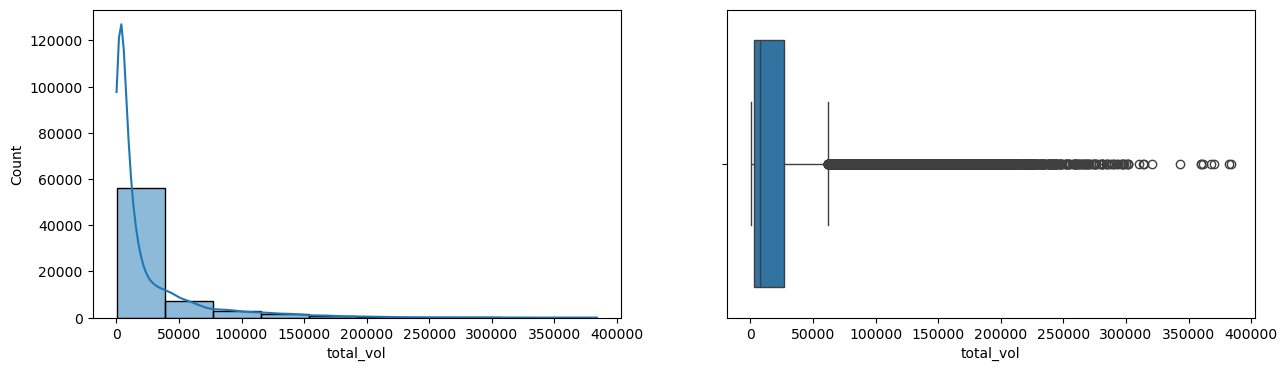

total_dpm
Skew : 3.53


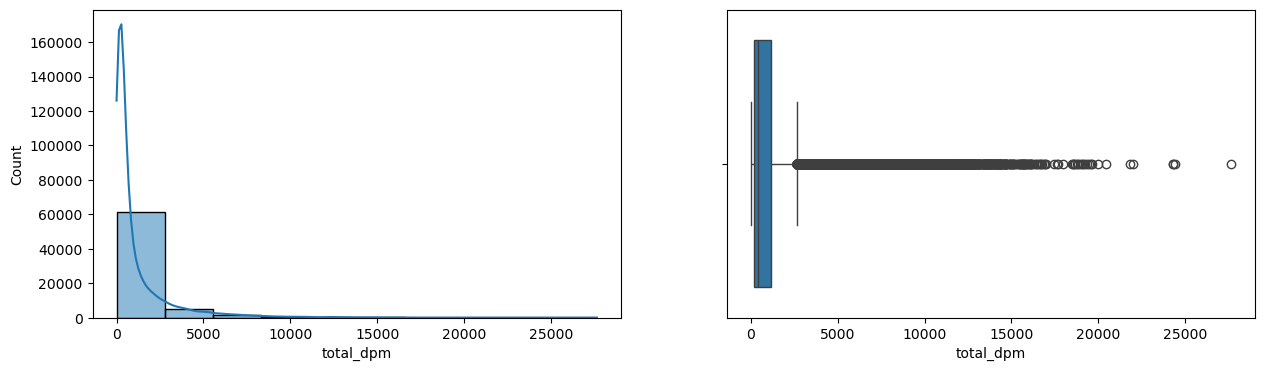

national_volume
Skew : 3.27


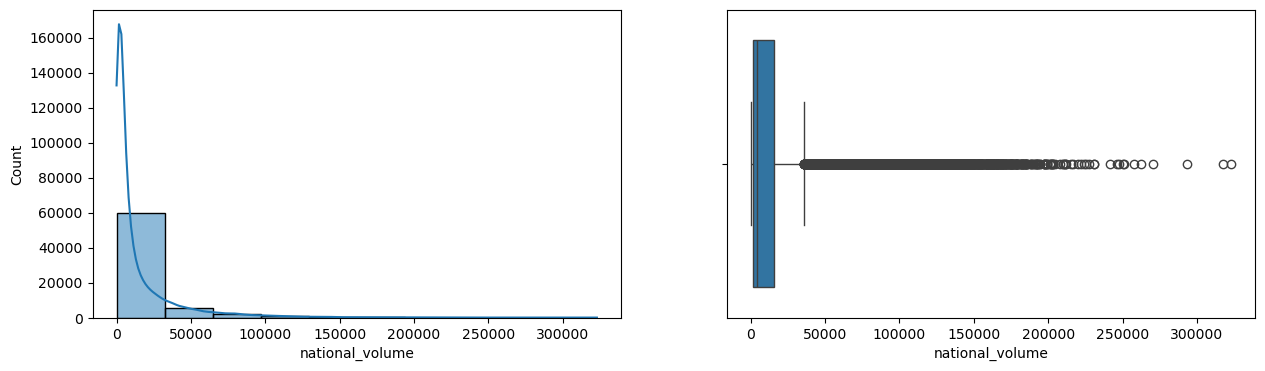

international_volume
Skew : 3.86


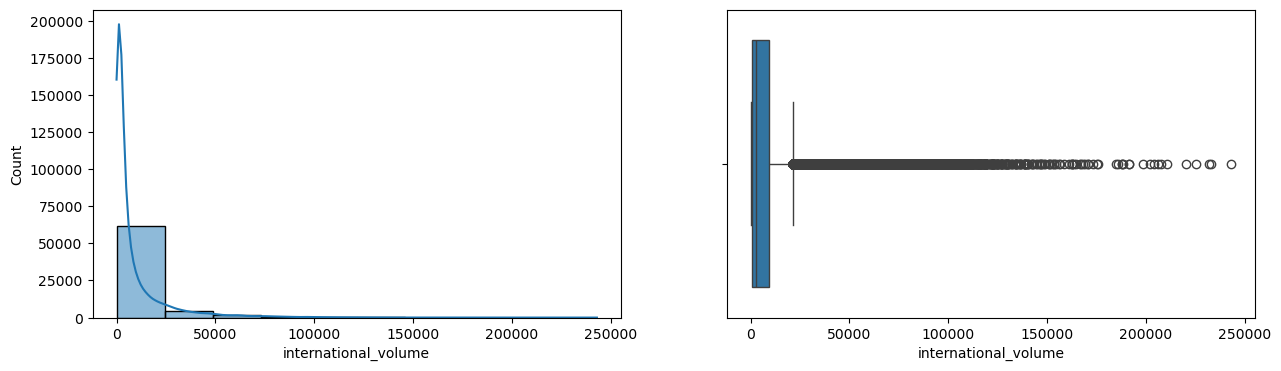

supplied_by_bp_vol
Skew : 3.43


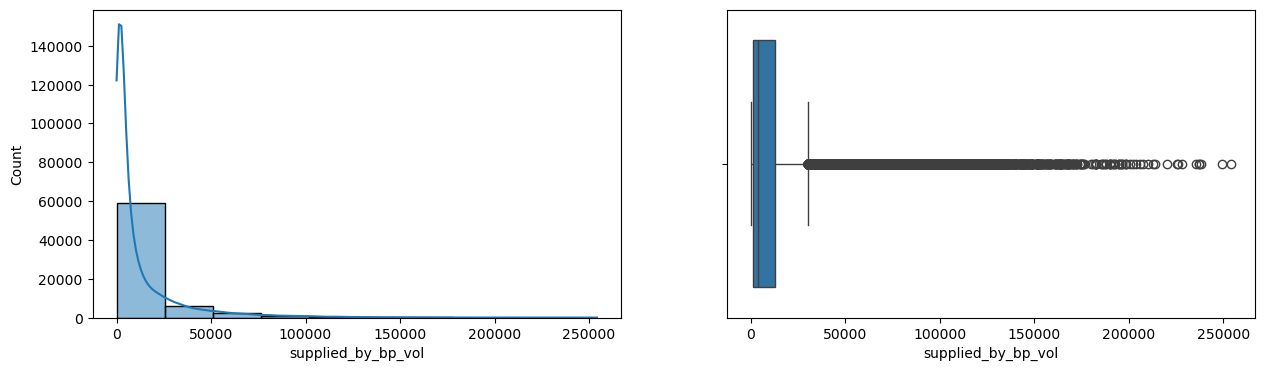

non_supplied_by_bp_vol
Skew : 3.58


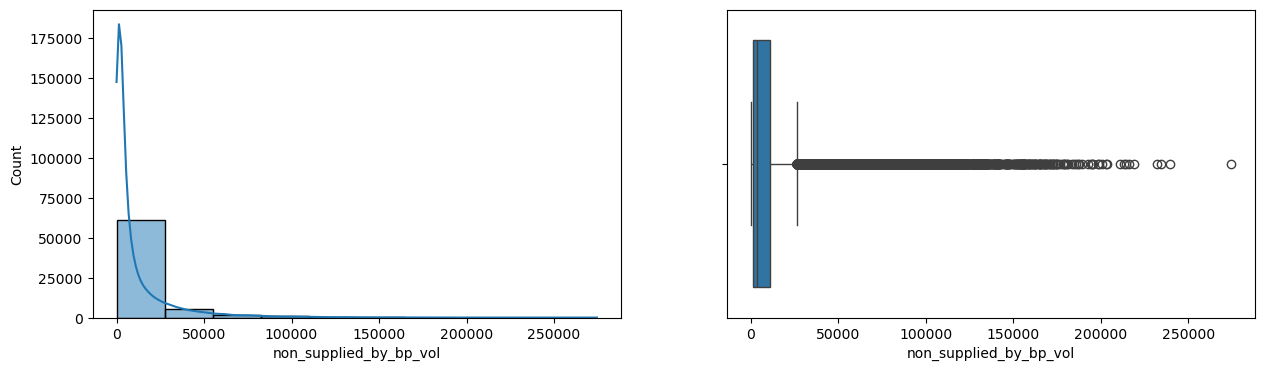

non_street_heavy_sites_volume
Skew : 3.34


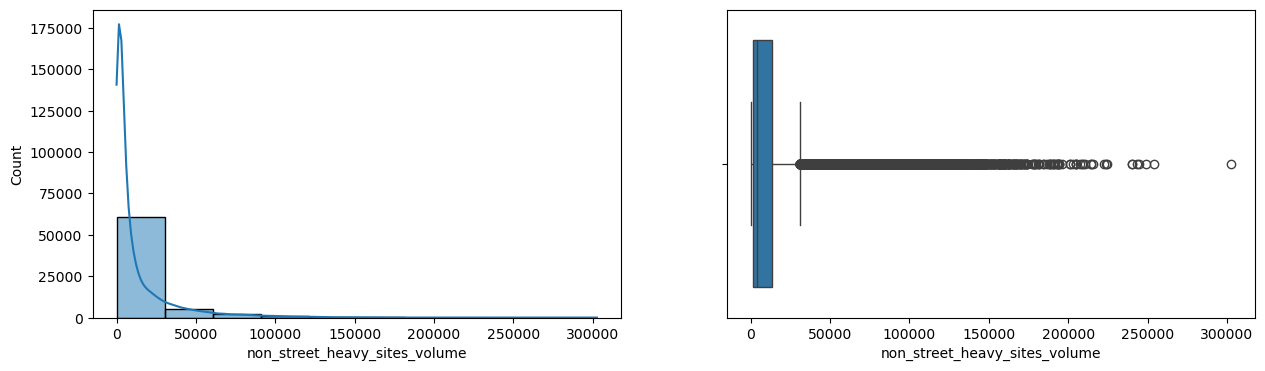

street_heavy_sites_volume
Skew : 3.62


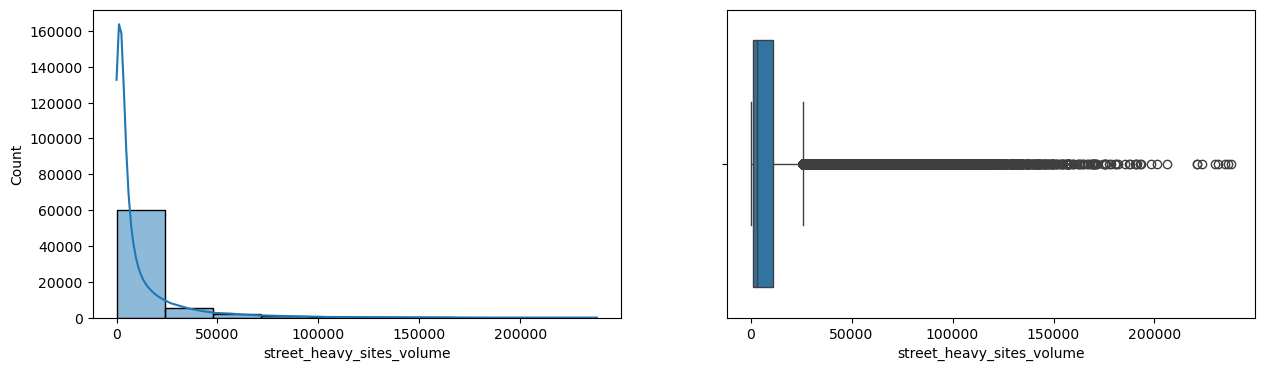

dealer_heavy_site_type_volume
Skew : 3.68


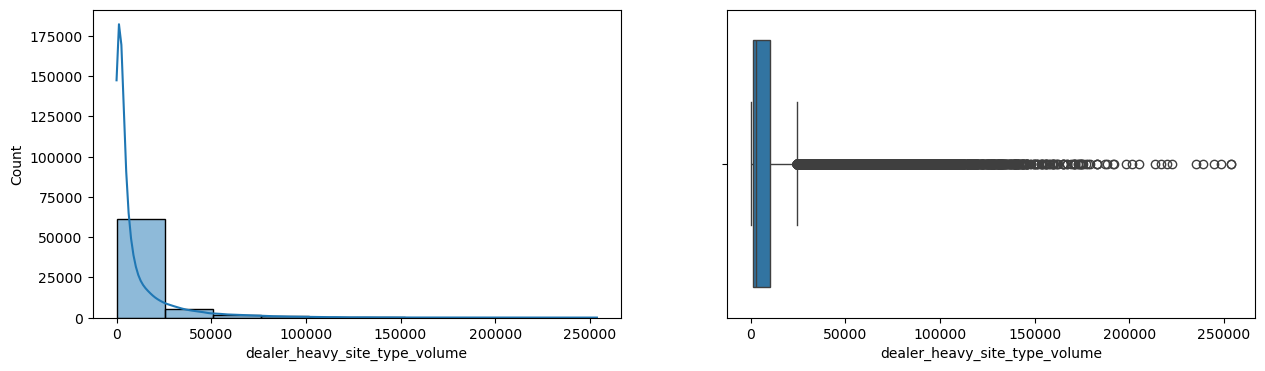

bp_heavy_site_type_volume
Skew : 3.42


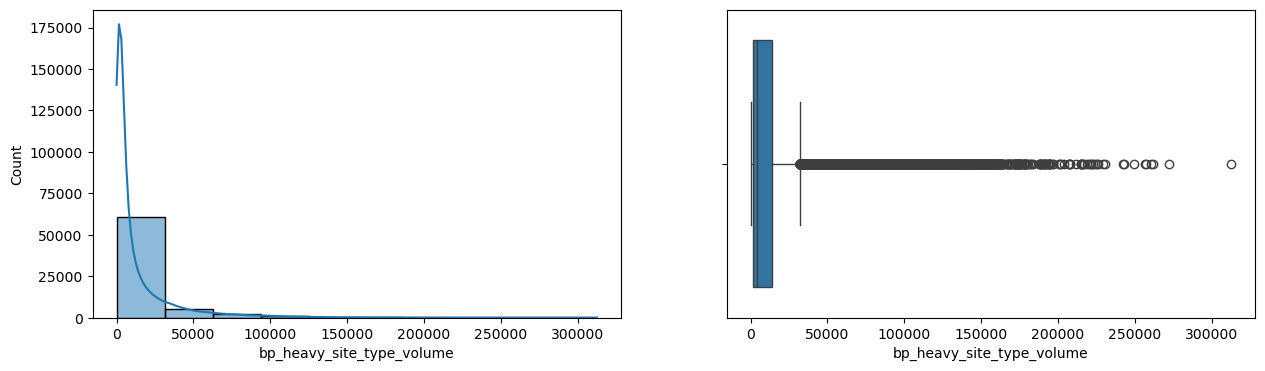

supplied_by_bp_median_rebate_cpl
Skew : 0.01


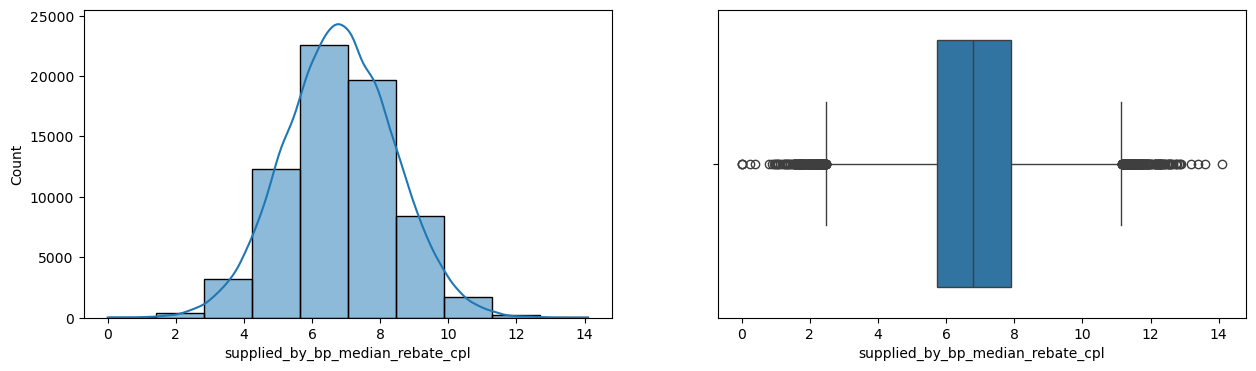

non_supplied_by_bp_median_rebate_cpl
Skew : -0.02


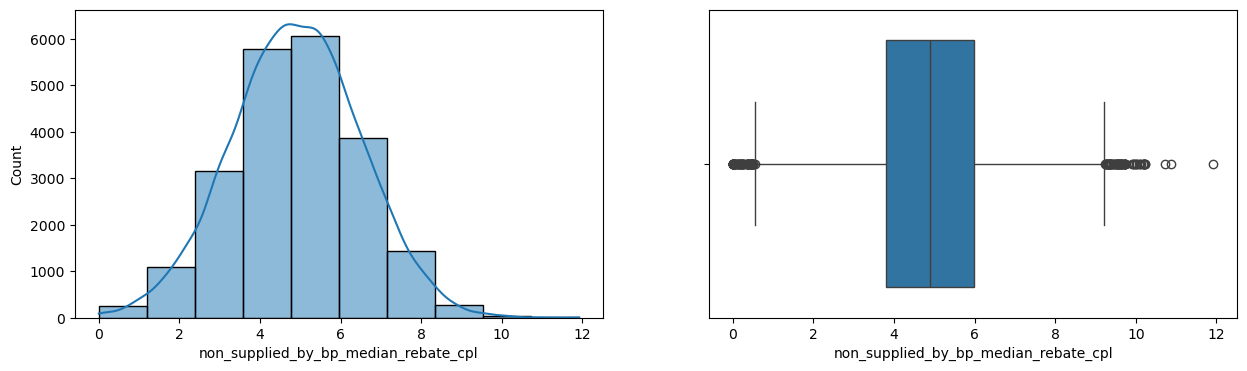

non_street_heavy_sites_median_rebate_cpl
Skew : -0.0


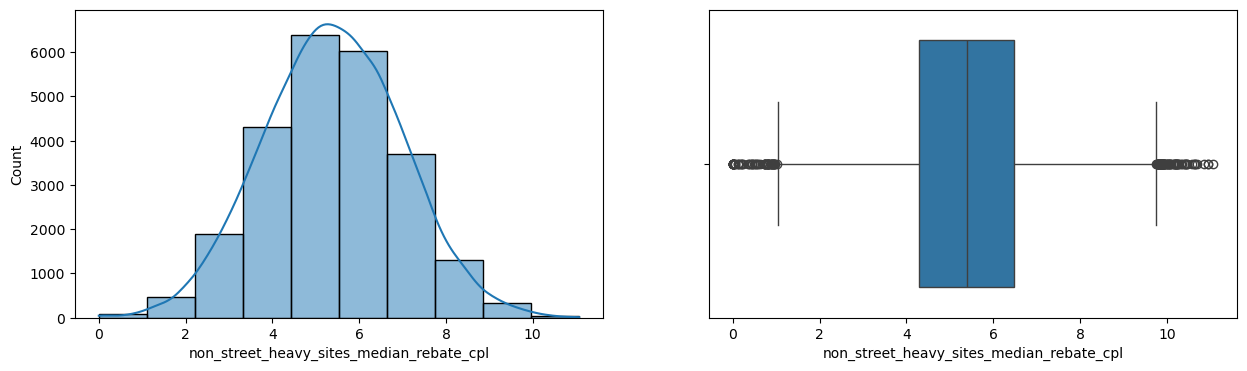

street_heavy_sites_median_rebate_cpl
Skew : 0.01


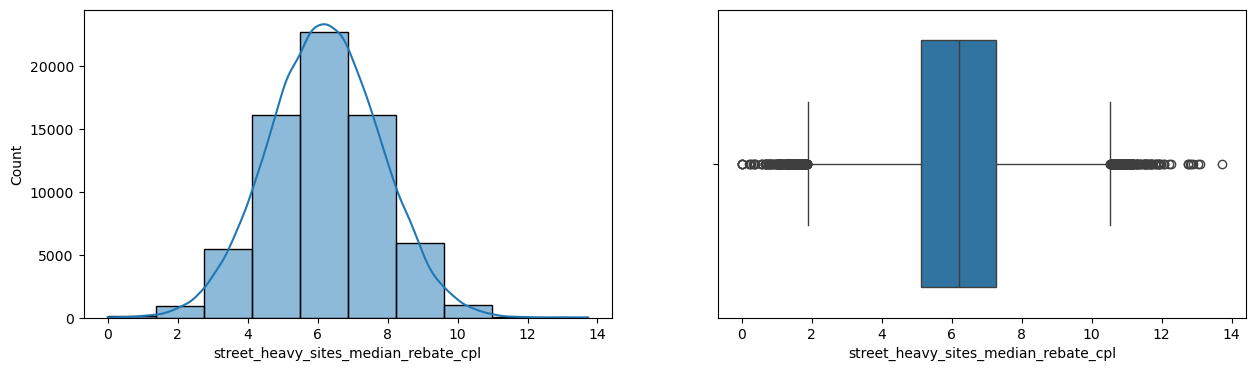

dealer_heavy_sites_median_rebate_cpl
Skew : 0.0


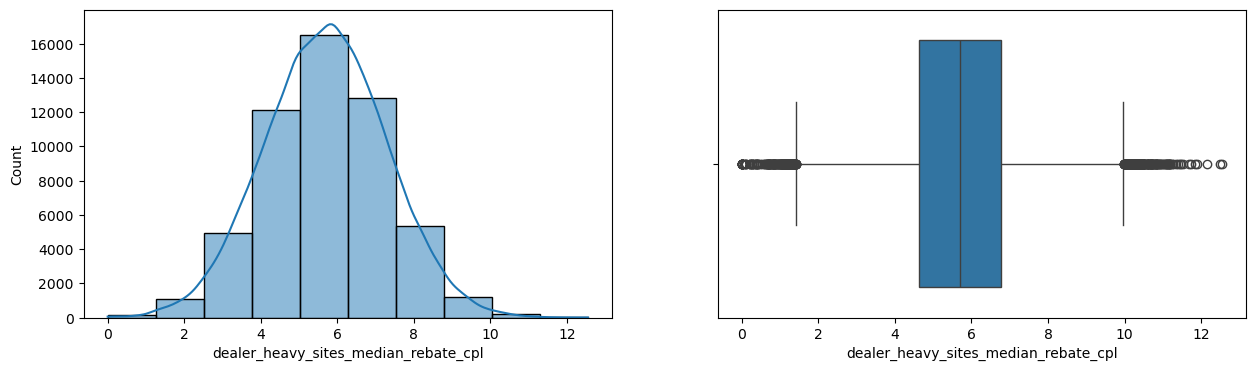

bp_heavy_sites_median_rebate_cpl
Skew : 0.01


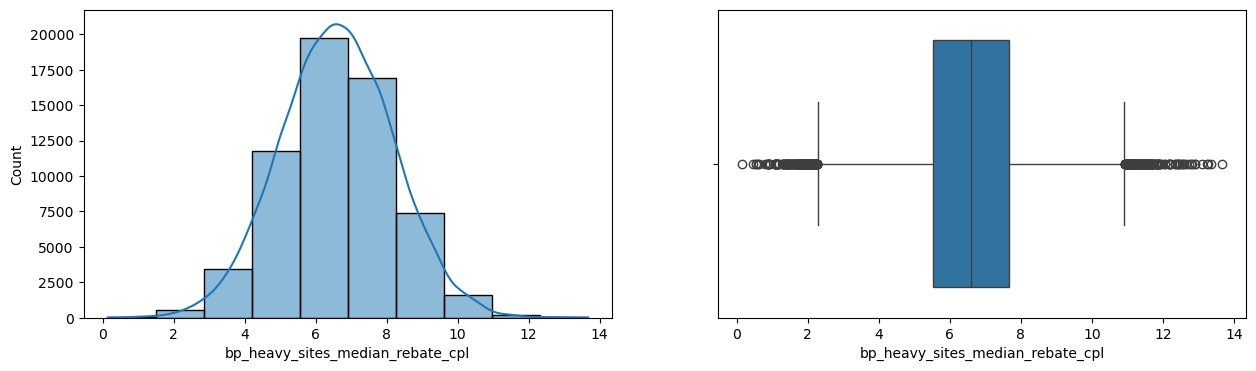

overall_median_rebate_cpl
Skew : 0.01


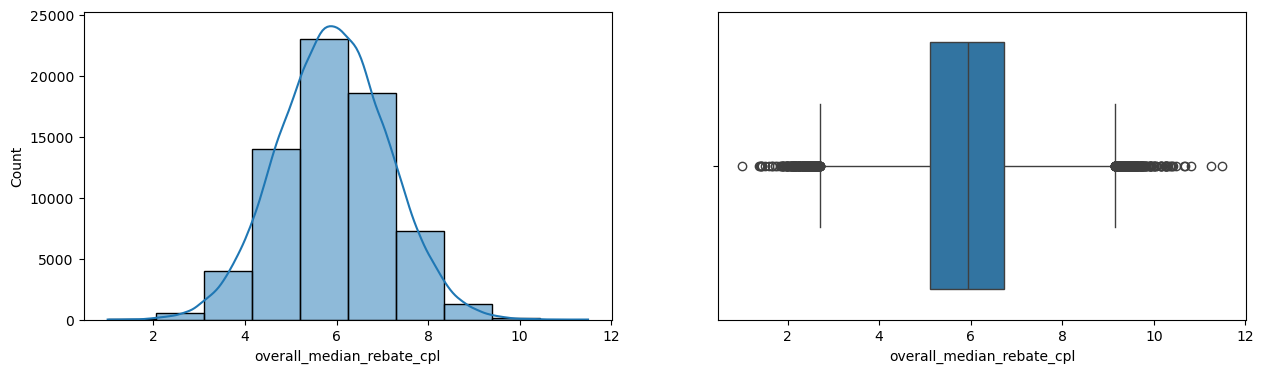

used_retail_sites_count
Skew : 3.17


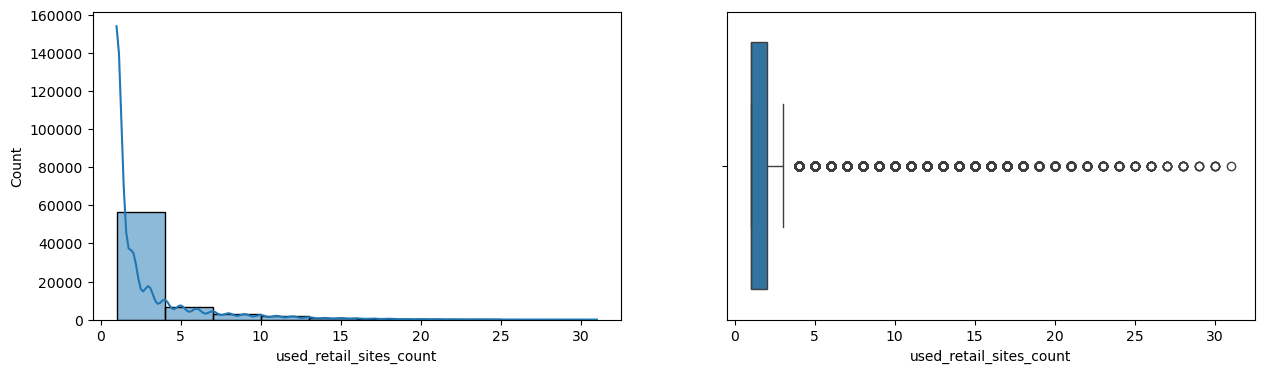

total_rebate_amount
Skew : 3.0


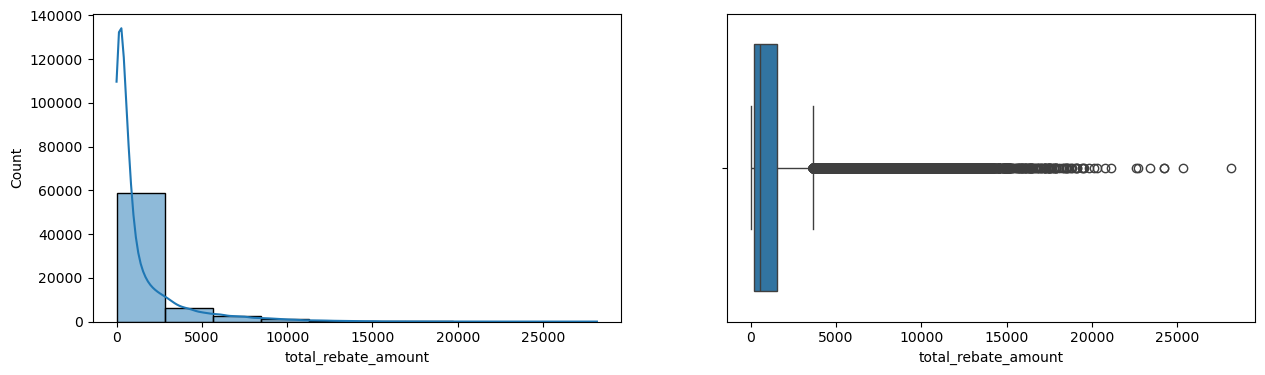

contract_age
Skew : 0.0


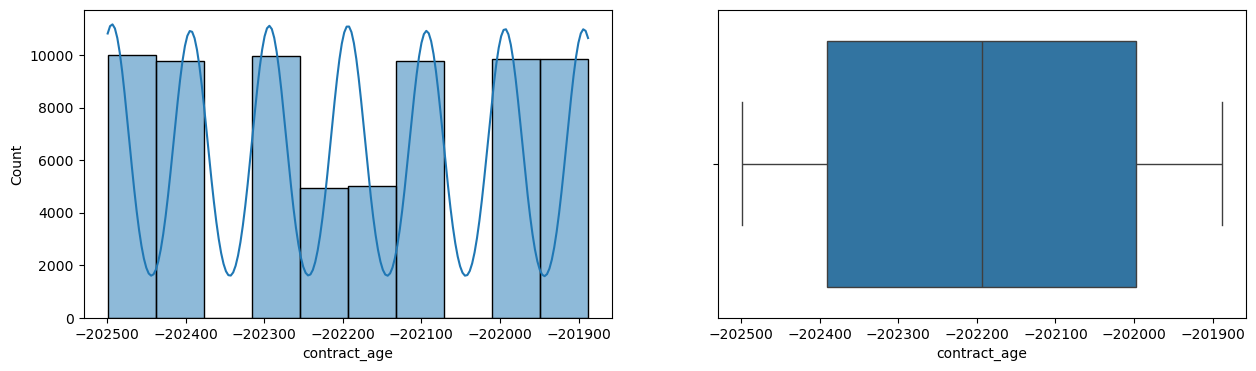

In [9]:
result = customer_segmentation.select_dtypes(include='number')

cont_cols = list(result.columns)

for col in cont_cols:

    print(col)
    print('Skew :', round(customer_segmentation[col].skew(), 2))

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(customer_segmentation[col], bins=10, kde=True)
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=customer_segmentation[col])

    plt.show()

In [10]:
#Create a copy of the dataset
customer_segmentation_cp = customer_segmentation.drop(
    [
        'parent_name',
        'supplied_by_bp_median_rebate_cpl',
        'non_supplied_by_bp_median_rebate_cpl',
        'non_street_heavy_sites_median_rebate_cpl',
        'street_heavy_sites_median_rebate_cpl',
        'dealer_heavy_sites_median_rebate_cpl',
        'bp_heavy_sites_median_rebate_cpl',
        'overall_median_rebate_cpl',
        'total_rebate_amount'
    ],
    axis=1
)

### **Summary Statistics**

In [11]:
customer_segmentation_cp.head()

,product_category,total_vol,total_dpm,national_volume,international_volume,supplied_by_bp_vol,non_supplied_by_bp_vol,non_street_heavy_sites_volume,street_heavy_sites_volume,dealer_heavy_site_type_volume,bp_heavy_site_type_volume,used_retail_sites_count,applied_pricing_type_mode,contract_age
0,Gasoline,1264.10,135.44,773.79,490.31,492.93,771.17,620.78,643.32,455.81,808.29,1,Index,-202096
1,Diesel,3131.28,370.32,1026.52,2104.76,2660.31,470.97,2155.82,975.46,1002.07,2129.21,1,Index,-202096
2,Diesel,1568.87,152.72,799.82,769.05,1083.22,485.65,675.88,892.99,545.48,1023.39,3,Spot,-202290
3,Gasoline,57187.63,2503.23,46020.13,11167.50,24731.91,32455.72,45298.48,11889.15,34777.45,22410.18,4,Fixed,-202393
4,Diesel,3181.65,262.70,2580.88,600.77,821.67,2359.98,2532.04,649.61,903.79,2277.86,1,Index,-202096


In [12]:
customer_segmentation_cp.describe(
    percentiles=[0.25, 0.75,0.90, 0.95, 0.99]
).T.round(0)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
total_vol,69145.0,23335.0,36685.0,162.0,2733.0,7995.0,26497.0,66348.0,104740.0,173797.0,383888.0
total_dpm,69145.0,1111.0,1837.0,0.0,174.0,416.0,1170.0,3032.0,4848.0,9043.0,27628.0
national_volume,69145.0,14345.0,24022.0,26.0,1589.0,4620.0,15438.0,40649.0,64418.0,117695.0,322934.0
international_volume,69145.0,8990.0,16342.0,2.0,907.0,2663.0,9068.0,25129.0,40793.0,81722.0,243092.0
supplied_by_bp_vol,69145.0,12328.0,21190.0,21.0,1328.0,3855.0,12931.0,34719.0,55241.0,104505.0,254148.0
non_supplied_by_bp_vol,69145.0,11007.0,19369.0,11.0,1159.0,3378.0,11307.0,30947.0,49518.0,97642.0,274463.0
non_street_heavy_sites_volume,69145.0,12718.0,21620.0,18.0,1380.0,4022.0,13325.0,36222.0,56926.0,106531.0,302595.0
street_heavy_sites_volume,69145.0,10617.0,18756.0,7.0,1107.0,3237.0,10951.0,29782.0,47643.0,93674.0,237899.0
dealer_heavy_site_type_volume,69145.0,10237.0,18214.0,8.0,1051.0,3073.0,10457.0,28833.0,46185.0,90322.0,253748.0
bp_heavy_site_type_volume,69145.0,13098.0,22473.0,4.0,1422.0,4105.0,13740.0,37083.0,58875.0,110875.0,312496.0


**Observations:**

Most of the data is highly skewed

**Let's check the distribution and outliers for numerical columns in the data**

total_vol
Skew : 2.82


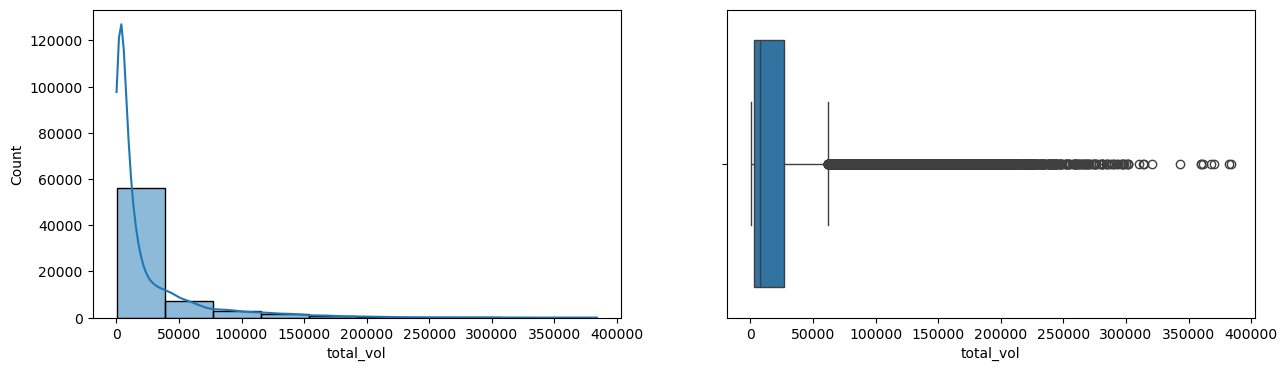

total_dpm
Skew : 3.53


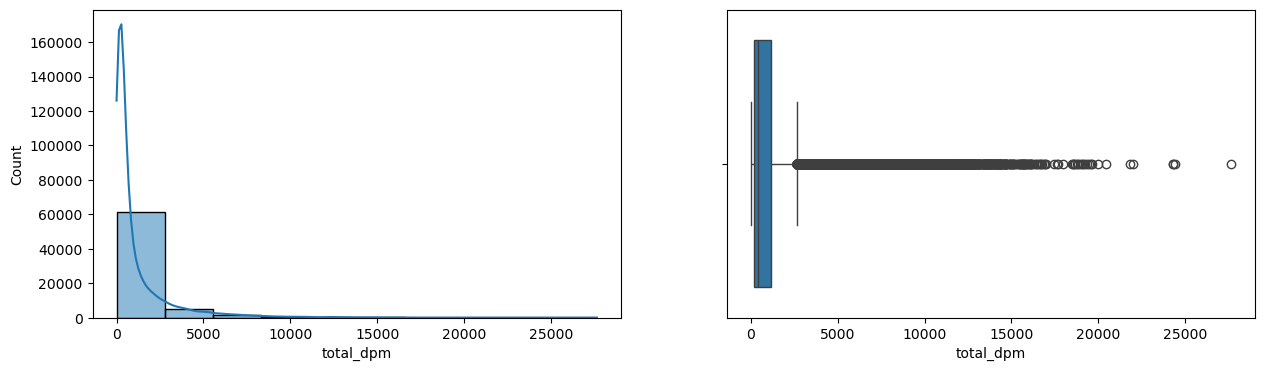

national_volume
Skew : 3.27


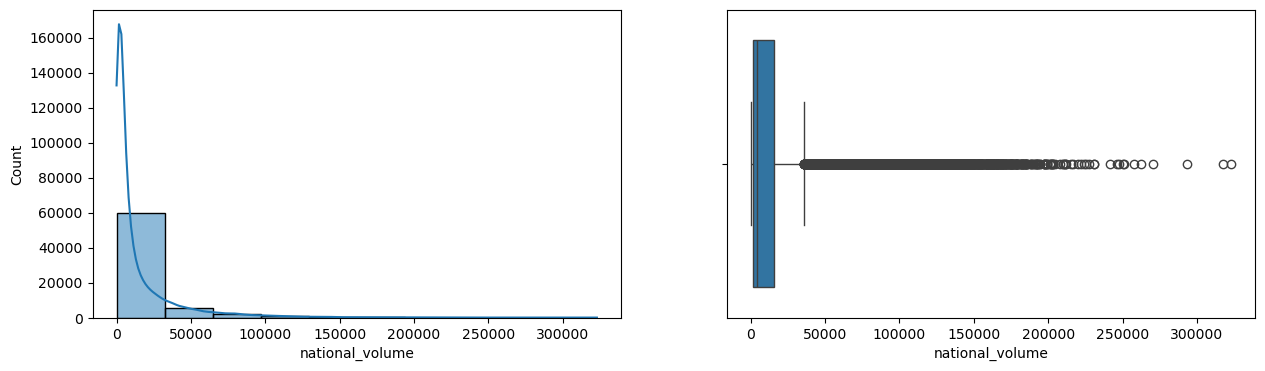

international_volume
Skew : 3.86


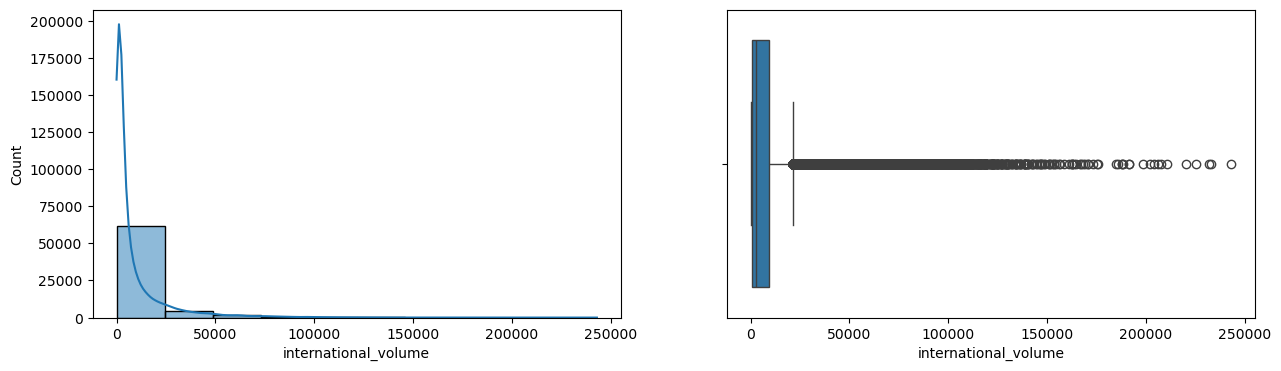

supplied_by_bp_vol
Skew : 3.43


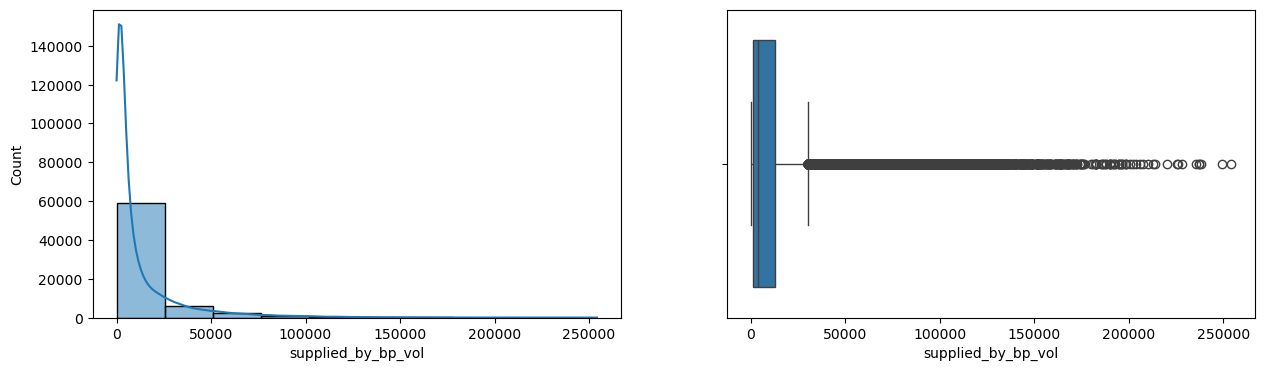

non_supplied_by_bp_vol
Skew : 3.58


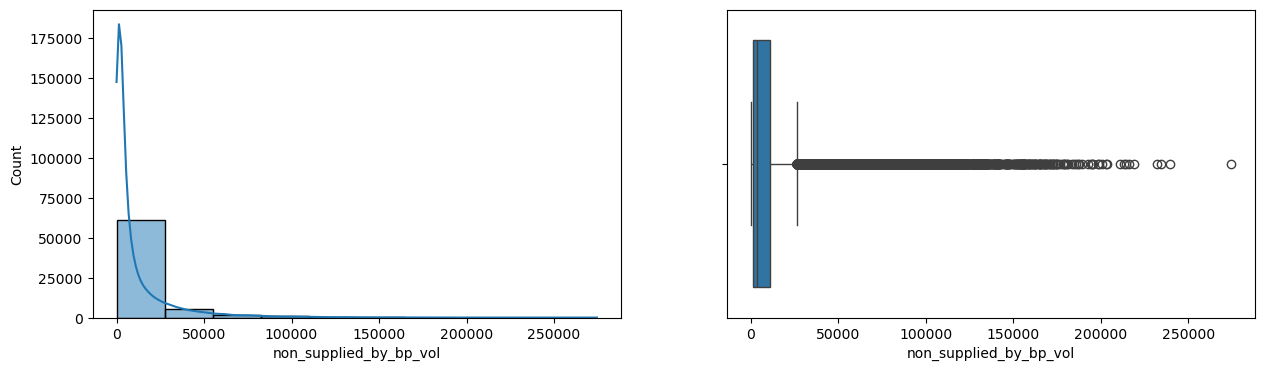

non_street_heavy_sites_volume
Skew : 3.34


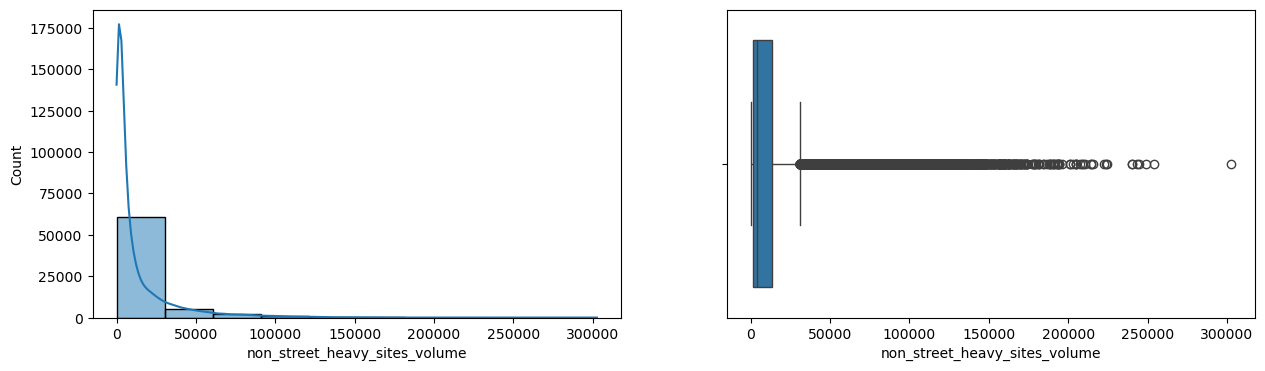

street_heavy_sites_volume
Skew : 3.62


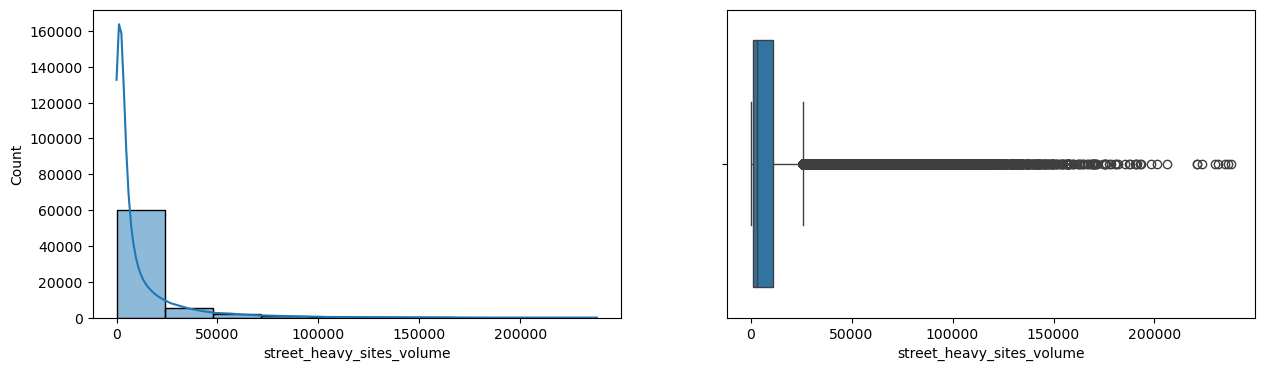

dealer_heavy_site_type_volume
Skew : 3.68


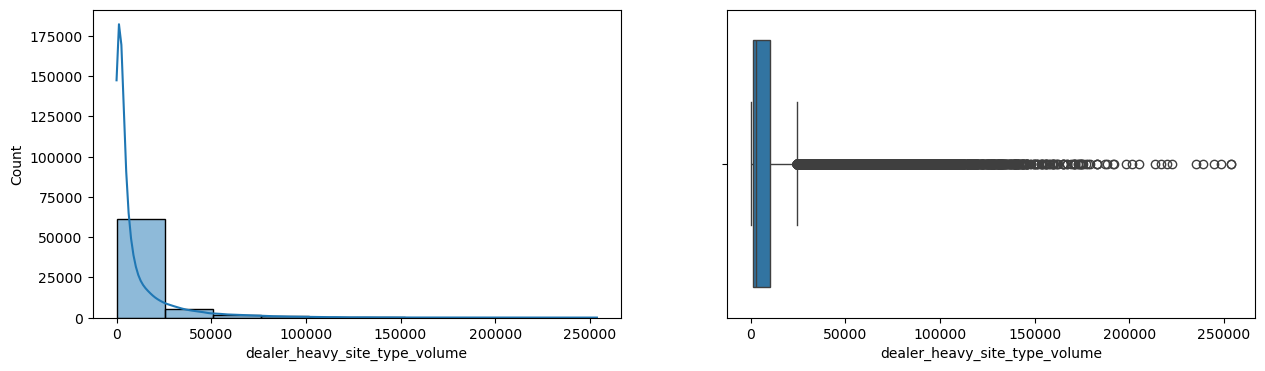

bp_heavy_site_type_volume
Skew : 3.42


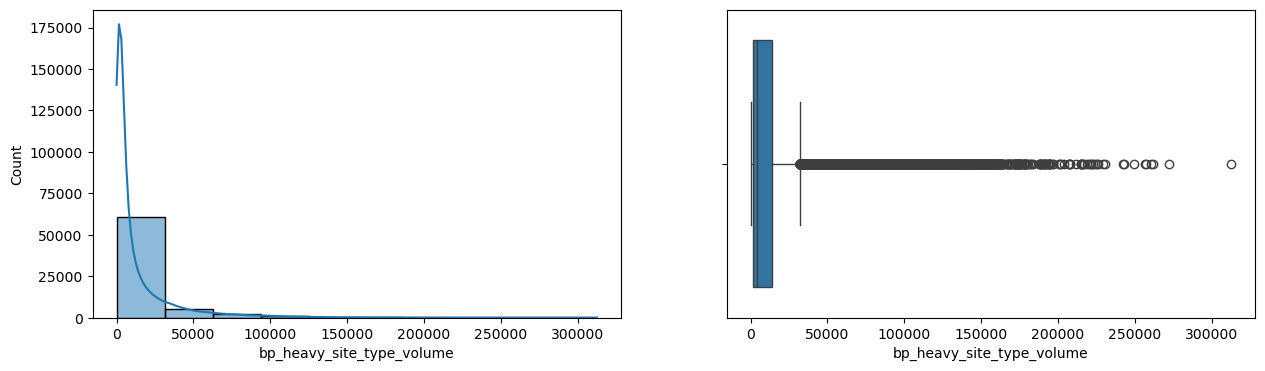

used_retail_sites_count
Skew : 3.17


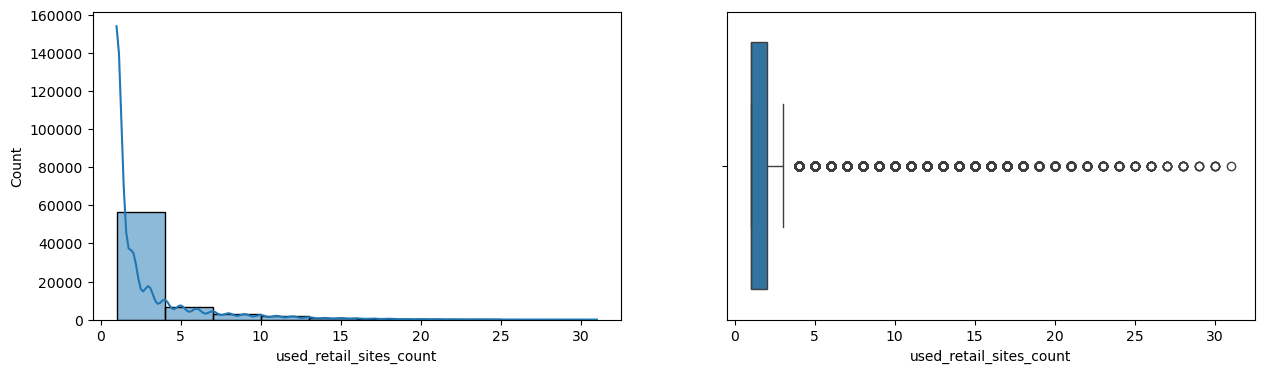

contract_age
Skew : 0.0


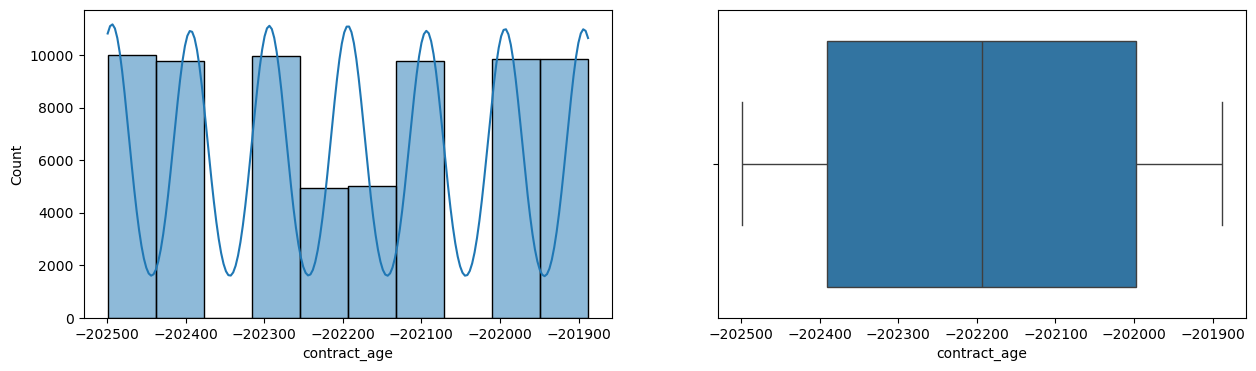

In [13]:
result = customer_segmentation_cp.select_dtypes(include='number')

cont_cols = list(result.columns)

for col in cont_cols:

    print(col)
    print('Skew :', round(customer_segmentation_cp[col].skew(), 2))

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(customer_segmentation_cp[col], bins=10, kde=True)
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=customer_segmentation_cp[col])

    plt.show()

In [14]:
numeric_cols = customer_segmentation_cp.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if customer_segmentation_cp[col].min() < 0:
        customer_segmentation_cp[col] = (
            np.sign(customer_segmentation_cp[col]) *
            np.log1p(np.abs(customer_segmentation_cp[col]))
        )
    else:
        customer_segmentation_cp[col] = np.log1p(customer_segmentation_cp[col])

total_vol
Skew : 0.21


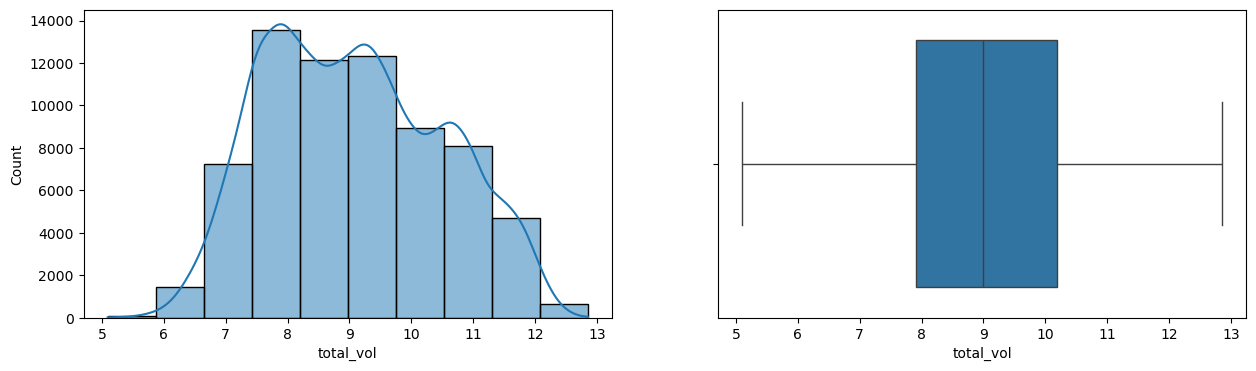

total_dpm
Skew : -1.33


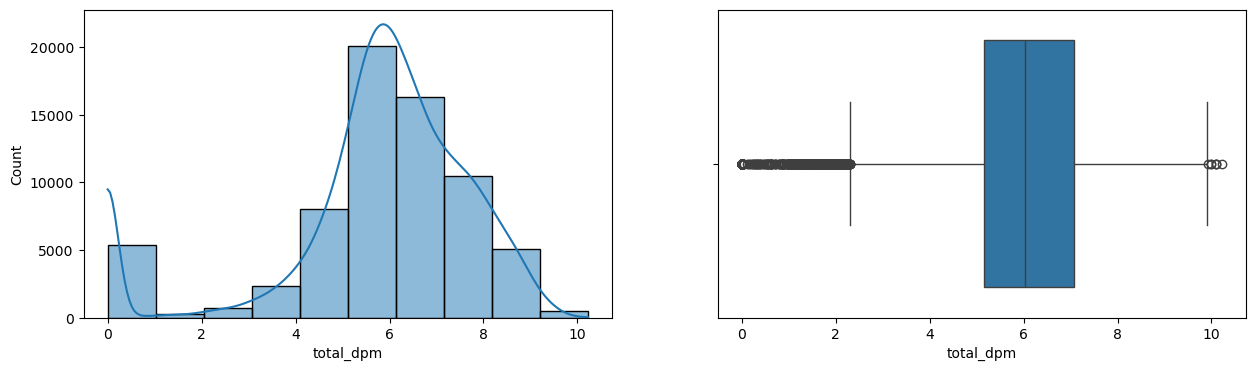

national_volume
Skew : 0.17


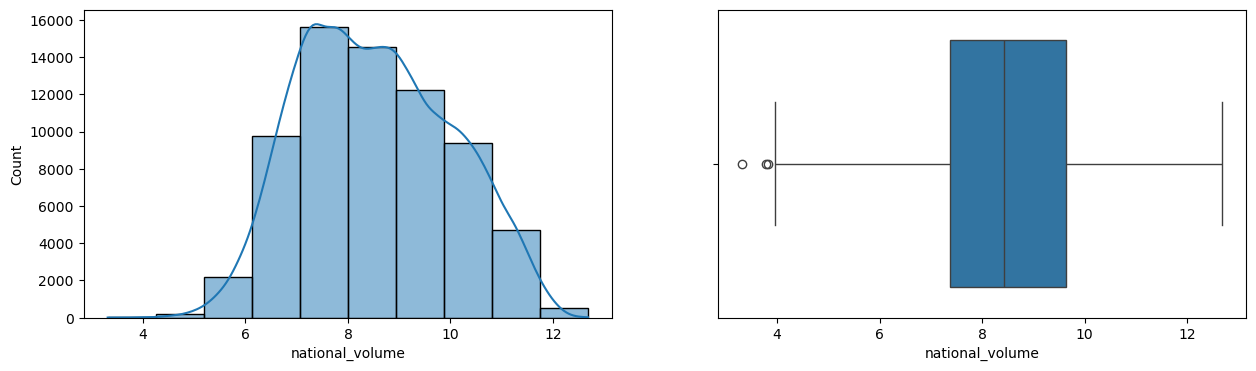

international_volume
Skew : 0.09


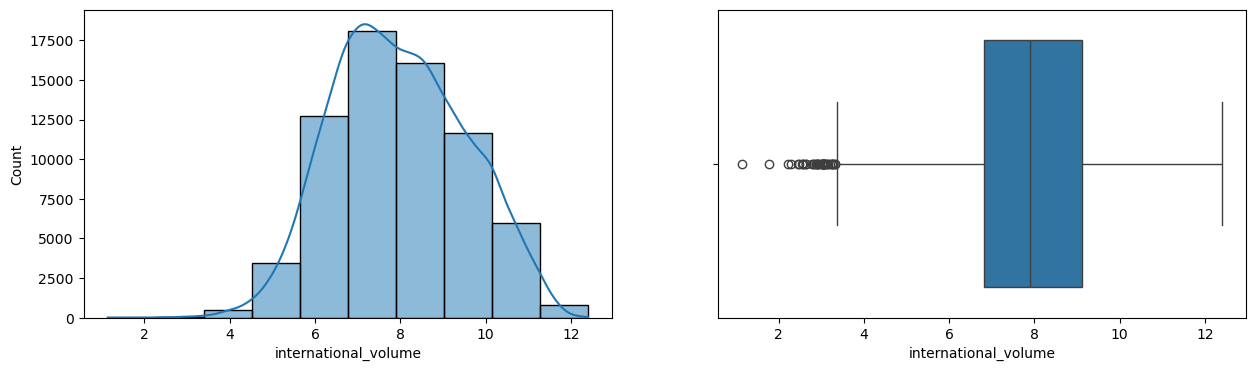

supplied_by_bp_vol
Skew : 0.14


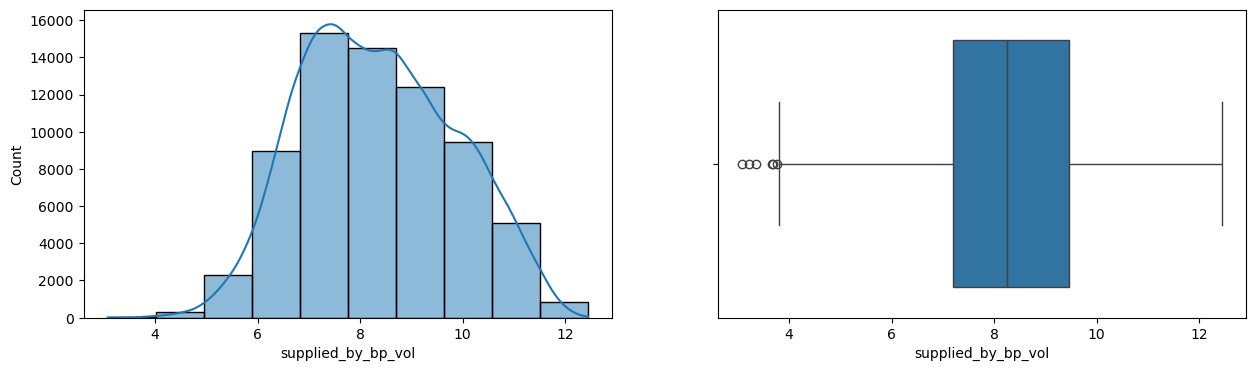

non_supplied_by_bp_vol
Skew : 0.12


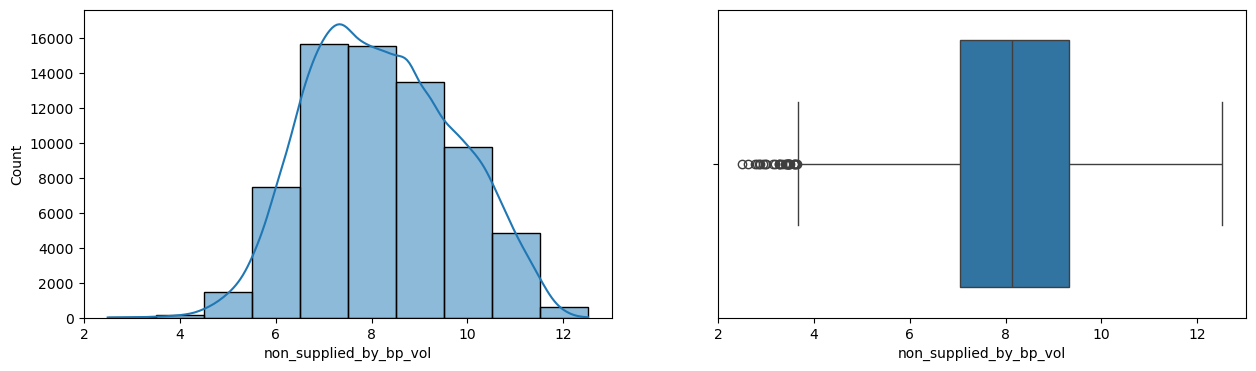

non_street_heavy_sites_volume
Skew : 0.15


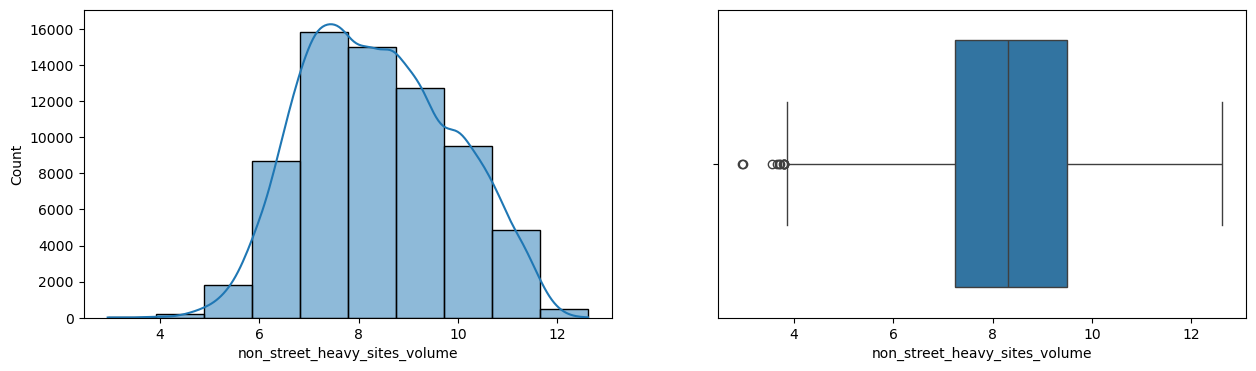

street_heavy_sites_volume
Skew : 0.12


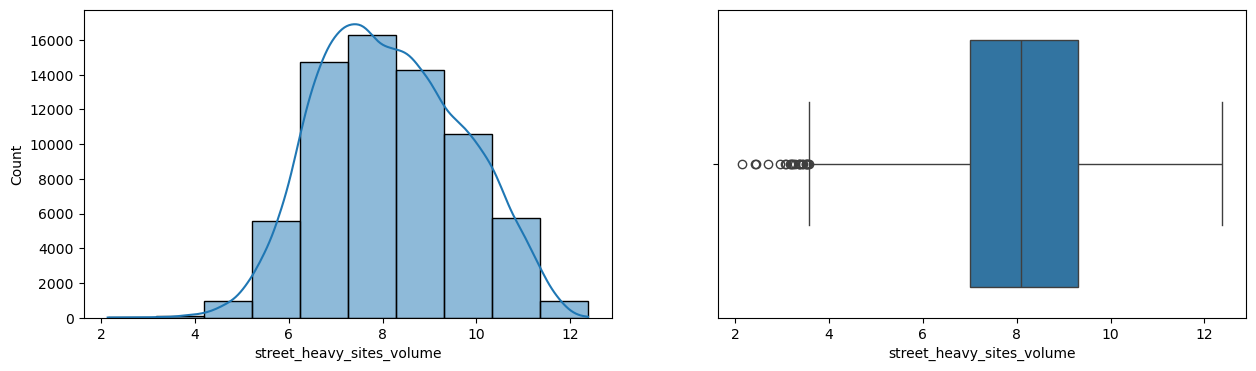

dealer_heavy_site_type_volume
Skew : 0.09


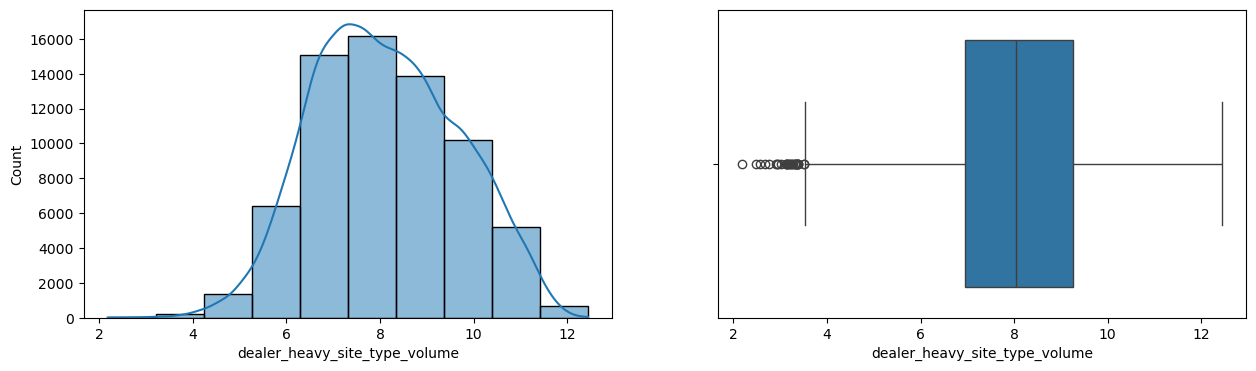

bp_heavy_site_type_volume
Skew : 0.14


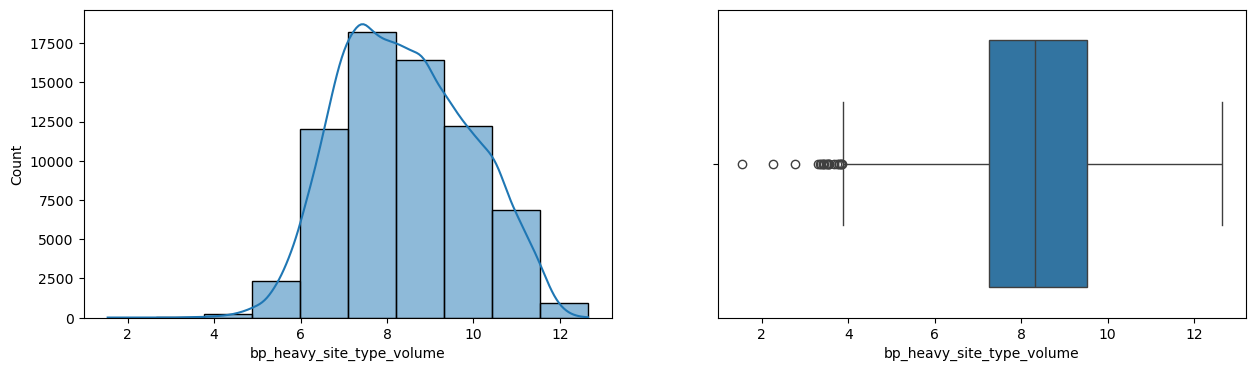

used_retail_sites_count
Skew : 1.62


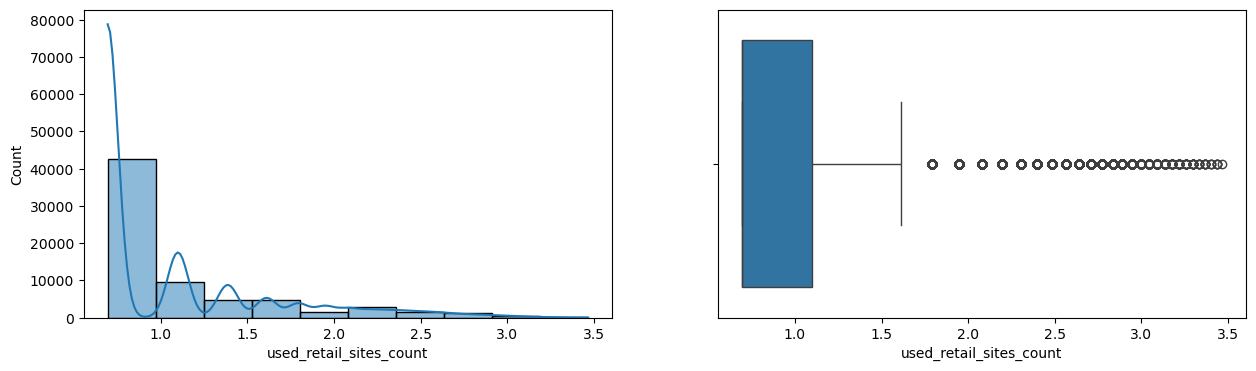

contract_age
Skew : 0.01


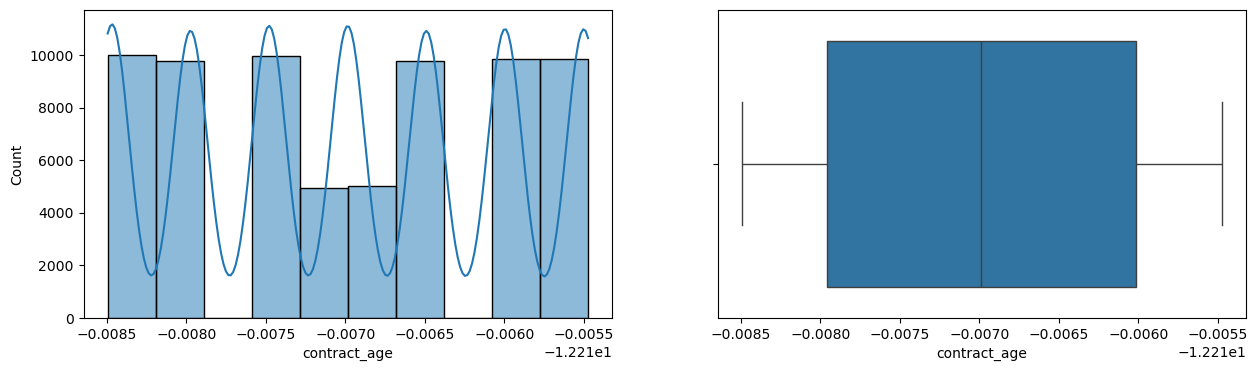

In [15]:
result = customer_segmentation_cp.select_dtypes(include='number')

cont_cols = list(result.columns)

for col in cont_cols:

    print(col)
    print('Skew :', round(customer_segmentation_cp[col].skew(), 2))

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(customer_segmentation_cp[col], bins=10, kde=True)
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=customer_segmentation_cp[col])

    plt.show()

**Now, let's check the correlation among different variables**

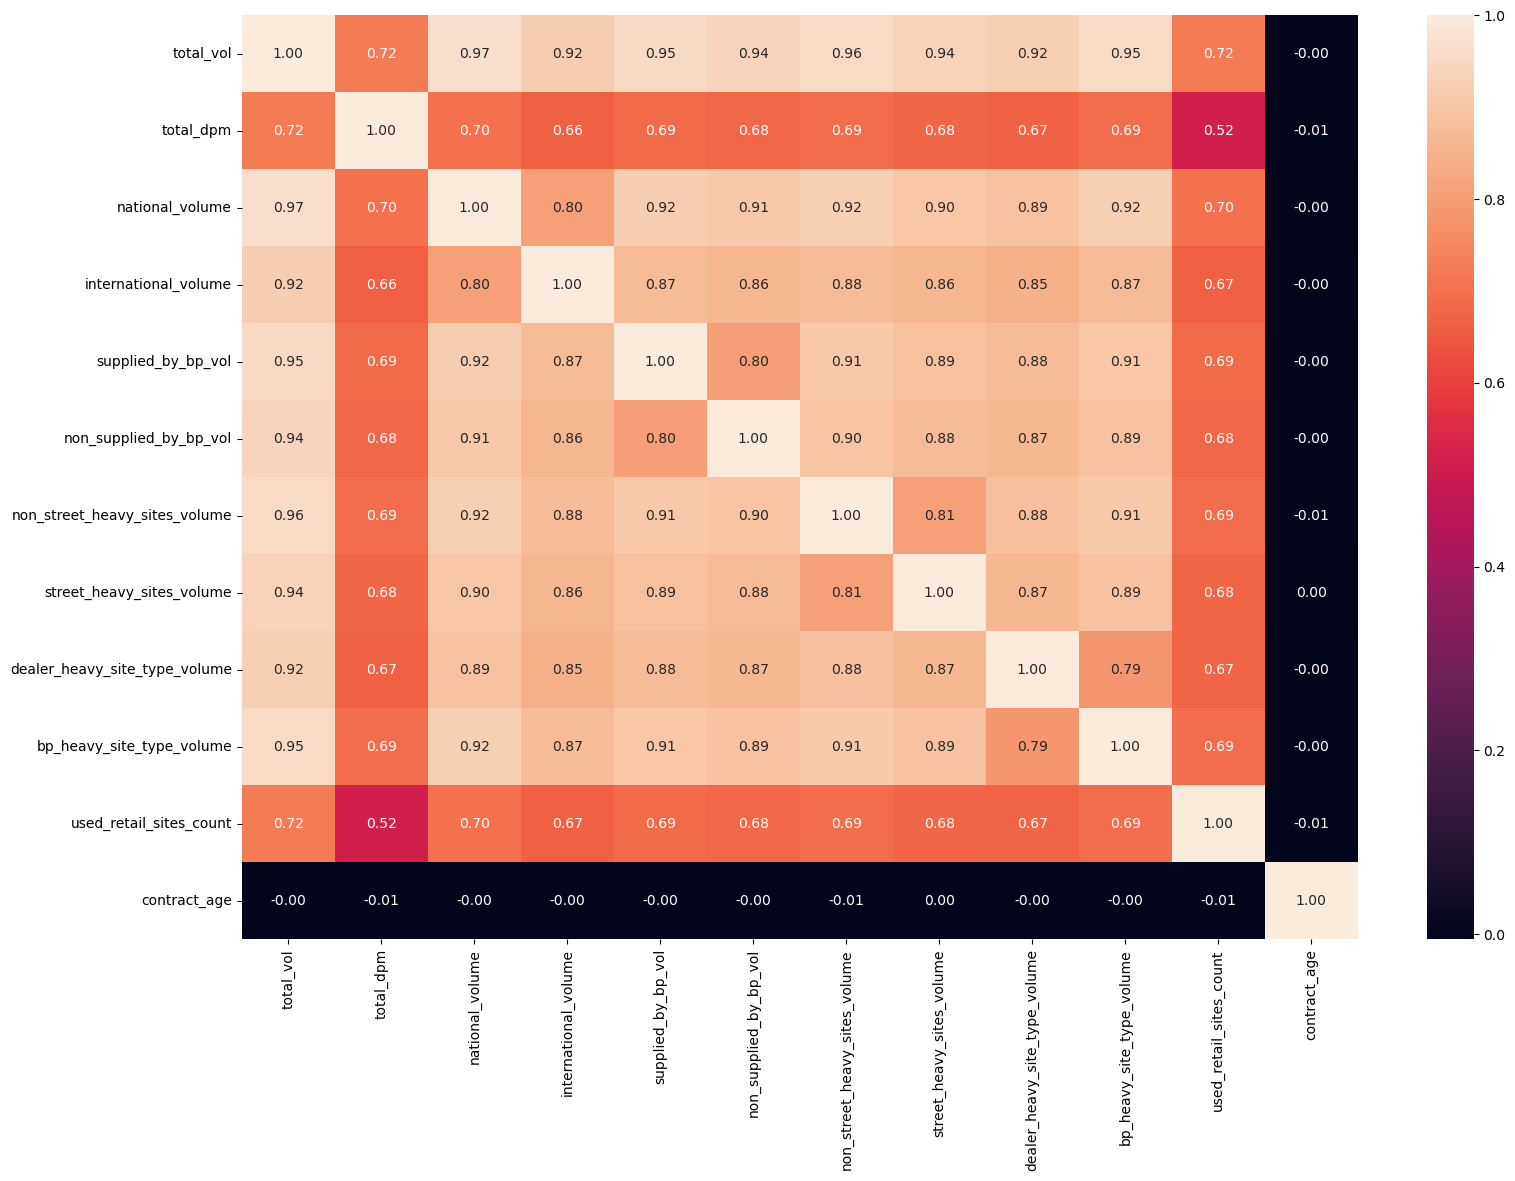

In [16]:
plt.figure(figsize = (18, 12))

sns.heatmap(customer_segmentation_cp.corr(numeric_only = True), annot = True, fmt = '0.2f')

plt.show()

**Observations:**

The data shows high correlation, indicating there is a high degree of multicollinearity among the features.

In [17]:
# Creating dummy variables for Weather column
customer_segmentation_cp = pd.get_dummies(customer_segmentation_cp, drop_first = True)

In [18]:
customer_segmentation_cp.head()

,total_vol,total_dpm,national_volume,international_volume,supplied_by_bp_vol,non_supplied_by_bp_vol,non_street_heavy_sites_volume,street_heavy_sites_volume,dealer_heavy_site_type_volume,bp_heavy_site_type_volume,...,contract_age,product_category_Diesel,product_category_Gasoline,product_category_Kerosene,product_category_Lubricants,product_category_Premium Diesel,applied_pricing_type_mode_Fixed,applied_pricing_type_mode_Index,applied_pricing_type_mode_Mixed,applied_pricing_type_mode_Spot
0,7.142906,4.915885,6.652592,6.197075,6.202394,6.649205,6.432586,6.468195,6.124268,6.696157,...,-12.216503,False,True,False,False,False,False,True,False,False
1,8.049516,5.917064,6.934903,7.652432,7.886574,6.156915,7.676390,6.883934,6.910821,7.663976,...,-12.216503,True,False,False,False,False,False,True,False,False
2,7.358748,5.035133,6.685636,6.646455,6.988616,6.187545,6.517494,6.795695,6.303498,6.931853,...,-12.217463,True,False,False,False,False,False,False,False,True
3,10.954110,7.825737,10.736856,9.320853,10.115890,10.387663,10.721051,9.383466,10.456753,10.017315,...,-12.217972,False,True,False,False,False,True,False,False,False
4,8.065469,5.574812,7.856273,6.399875,6.712555,7.766832,7.837175,6.477910,6.807703,7.731431,...,-12.216503,True,False,False,False,False,False,True,False,False


In [19]:
customer_segmentation_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69145 entries, 0 to 69144
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   total_vol                        69145 non-null  float64
 1   total_dpm                        69145 non-null  float64
 2   national_volume                  69145 non-null  float64
 3   international_volume             69145 non-null  float64
 4   supplied_by_bp_vol               69145 non-null  float64
 5   non_supplied_by_bp_vol           69145 non-null  float64
 6   non_street_heavy_sites_volume    69145 non-null  float64
 7   street_heavy_sites_volume        69145 non-null  float64
 8   dealer_heavy_site_type_volume    69145 non-null  float64
 9   bp_heavy_site_type_volume        69145 non-null  float64
 10  used_retail_sites_count          69145 non-null  float64
 11  contract_age                     69145 non-null  float64
 12  product_category_D

#### **Scaling the data**

In [20]:
import numpy as np

# Find columns containing inf values
#customer_segmentation_cp.columns[np.isinf(customer_segmentation_cp).any()]

In [21]:
#(customer_segmentation_cp['total_dpm'] == 0).sum()

In [22]:
scaler = StandardScaler()
customer_segmentation_scaled = scaler.fit_transform(customer_segmentation_cp)

In [23]:
customer_segmentation_scaled = pd.DataFrame(customer_segmentation_scaled, columns = customer_segmentation_cp.columns)

In [24]:
customer_segmentation_scaled

,total_vol,total_dpm,national_volume,international_volume,supplied_by_bp_vol,non_supplied_by_bp_vol,non_street_heavy_sites_volume,street_heavy_sites_volume,dealer_heavy_site_type_volume,bp_heavy_site_type_volume,...,contract_age,product_category_Diesel,product_category_Gasoline,product_category_Kerosene,product_category_Lubricants,product_category_Premium Diesel,applied_pricing_type_mode_Fixed,applied_pricing_type_mode_Index,applied_pricing_type_mode_Mixed,applied_pricing_type_mode_Spot
0,-1.352374,-0.402114,-1.269521,-1.138387,-1.424076,-1.024235,-1.307004,-1.113232,-1.287901,-1.142530,...,0.490799,-0.962117,1.533463,-0.144331,-0.203092,-0.333989,-0.624916,1.463298,-0.253044,-0.403321
1,-0.719207,0.072033,-1.078861,-0.204783,-0.306993,-1.346810,-0.476947,-0.841542,-0.779912,-0.498906,...,0.490799,1.039375,-0.652119,-0.144331,-0.203092,-0.333989,-0.624916,1.463298,-0.253044,-0.403321
2,-1.201632,-0.345640,-1.247204,-0.850112,-0.902590,-1.326740,-1.250341,-0.899207,-1.172146,-0.985787,...,-0.478736,1.039375,-0.652119,-0.144331,-0.203092,-0.333989,-0.624916,-0.683388,-0.253044,2.479417
3,1.309332,0.975958,1.488792,0.865501,1.171668,1.425411,1.554919,0.791937,1.510197,1.066126,...,-0.993112,-0.962117,1.533463,-0.144331,-0.203092,-0.333989,1.600215,-0.683388,-0.253044,-0.403321
4,-0.708065,-0.090054,-0.456613,-1.008291,-1.085696,-0.291903,-0.369646,-1.106884,-0.846510,-0.454047,...,0.490799,1.039375,-0.652119,-0.144331,-0.203092,-0.333989,-0.624916,1.463298,-0.253044,-0.403321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69140,0.347591,0.409545,0.396589,0.387062,0.716874,-0.410124,0.428480,0.350863,0.497847,0.308855,...,1.481285,1.039375,-0.652119,-0.144331,-0.203092,-0.333989,-0.624916,1.463298,-0.253044,-0.403321
69141,-0.126892,-0.113845,-0.609470,0.382074,-0.379512,0.190529,0.045673,-0.202576,0.044682,-0.128232,...,1.010933,-0.962117,1.533463,-0.144331,-0.203092,-0.333989,1.600215,-0.683388,-0.253044,-0.403321
69142,-0.736455,0.119216,-1.235749,-0.164466,-0.771865,-0.493220,-0.390411,-1.158250,-0.757251,-0.534899,...,-0.014075,-0.962117,-0.652119,-0.144331,-0.203092,-0.333989,-0.624916,-0.683388,-0.253044,-0.403321
69143,0.503347,0.297837,0.694628,0.180057,-0.111336,0.895677,0.765968,0.103535,0.481073,0.590908,...,1.501305,1.039375,-0.652119,-0.144331,-0.203092,-0.333989,-0.624916,1.463298,-0.253044,-0.403321


## **Principal Component Analysis**

In [25]:
# Defining the number of principal components to generate
n = customer_segmentation_scaled.shape[1]

# Finding principal components for the data
pca1 = PCA(n_components = n, random_state = 1)
customer_segmentation_pca = pd.DataFrame(pca1.fit_transform(customer_segmentation_scaled))
customer_segmentation_pca



,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,-3.716486,-1.640884,1.496633,-0.651504,-0.829918,-0.199971,-0.198752,-0.170141,0.431488,0.177545,...,0.223384,-0.126908,0.062152,0.274702,0.126337,0.082880,0.024817,-0.014543,0.004160,-0.062923
1,-2.093467,1.260428,1.525501,-0.585629,-0.274197,-0.157713,-0.093991,-0.135408,0.473833,0.505601,...,0.229406,-0.226403,0.581247,-0.782327,-0.198928,0.048472,0.141139,-0.115298,-0.091750,0.022887
2,-3.003439,1.248284,-0.220141,2.466341,-0.405967,-0.915455,0.101363,0.042980,-0.482368,-0.641831,...,0.303954,-0.143110,0.275370,-0.304241,0.280390,0.045442,0.032771,-0.002557,-0.009510,-0.053027
3,3.984749,-1.626445,-1.579310,-0.926774,-0.715731,-0.328031,-0.091251,0.088836,-1.013667,-0.029873,...,0.260912,0.355474,-0.364657,0.188822,-0.552966,0.092542,0.001276,0.080348,0.016951,-0.012476
4,-2.148697,1.264575,1.524419,-0.583652,-0.275525,-0.158542,-0.097000,-0.140515,0.473947,0.389658,...,0.231977,-0.270092,-0.398514,0.528504,-0.565490,0.068245,0.088943,-0.011983,0.037007,0.005718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69140,1.069026,1.253032,1.520843,-0.575252,-0.309583,-0.127484,-0.187267,-0.312273,1.452485,0.219548,...,0.243007,0.166144,0.022715,-0.811119,-0.016585,0.051964,0.133799,-0.200413,0.052974,-0.013434
69141,-0.447571,-1.629080,-1.580361,-0.909961,-0.760506,-0.229131,-0.271728,-0.278596,0.941015,0.365070,...,0.246371,0.055707,0.685431,0.384930,-0.171509,0.093046,0.075397,0.007057,-0.190726,0.003758
69142,-1.897548,-0.214753,-0.038611,0.124538,0.161599,0.074358,0.064231,0.028356,-0.016797,0.027811,...,-1.043401,-0.182916,0.739551,0.170936,-0.542284,-1.197975,0.076970,0.143150,-0.164347,0.016641
69143,1.611492,1.256088,1.519923,-0.571984,-0.317134,-0.134176,-0.193194,-0.322120,1.465606,-0.502013,...,0.239769,-0.054069,-0.303833,0.691373,-0.503204,0.071183,0.156870,-0.099198,0.053436,0.006543


In [26]:
# The percentage of variance explained by each principal component
exp_var1 = pca1.explained_variance_ratio_
exp_var1

array([4.39519609e-01, 7.82211936e-02, 6.80286627e-02, 5.81519922e-02,
       5.62941294e-02, 5.15733451e-02, 5.03171702e-02, 4.88475965e-02,
       4.75387280e-02, 2.30614320e-02, 1.97302650e-02, 1.27796474e-02,
       1.03069183e-02, 9.74830766e-03, 9.54894829e-03, 9.25864604e-03,
       4.44269085e-03, 9.29345698e-04, 8.43473454e-04, 7.54025401e-04,
       1.03873575e-04])

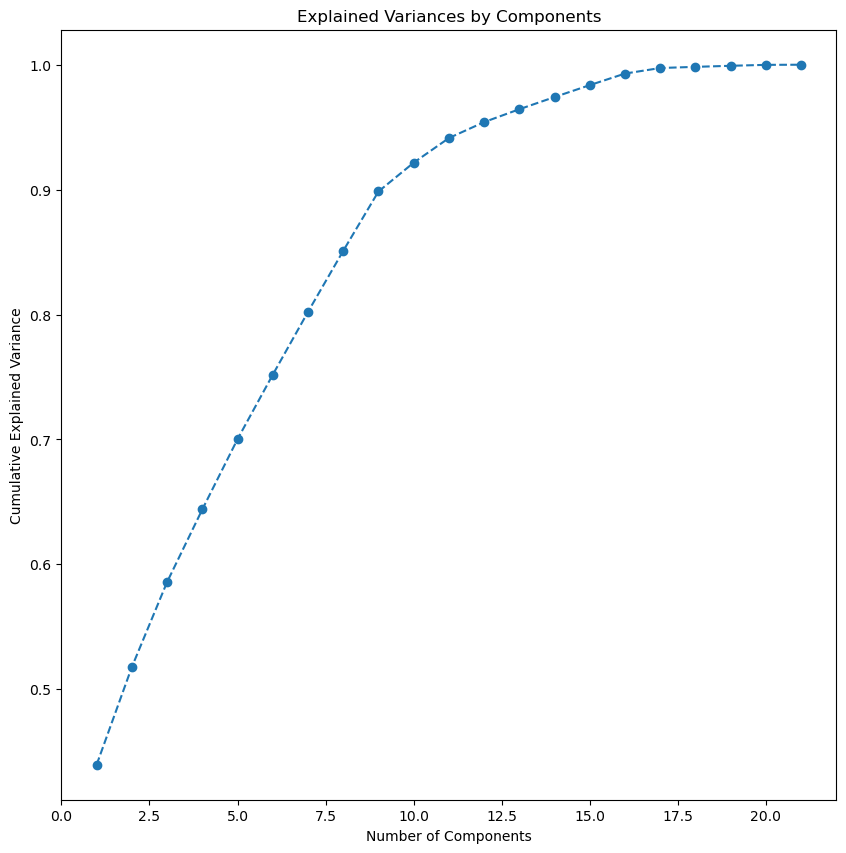

In [27]:
# Visualize the explained variance by individual components
plt.figure(figsize = (10, 10))
n= len(exp_var1)

plt.plot(range(1, n+1), pca1.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')

plt.title("Explained Variances by Components")

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.show()

In [28]:
# Find the least number of components that can explain more than 85% variance
sum = 0

for ix, i in enumerate(exp_var1):
    
    sum = sum + i
    
    if(sum>0.8):
        print("Number of PCs that explain at least 85% variance: ", ix + 1)
        break

Number of PCs that explain at least 85% variance:  7


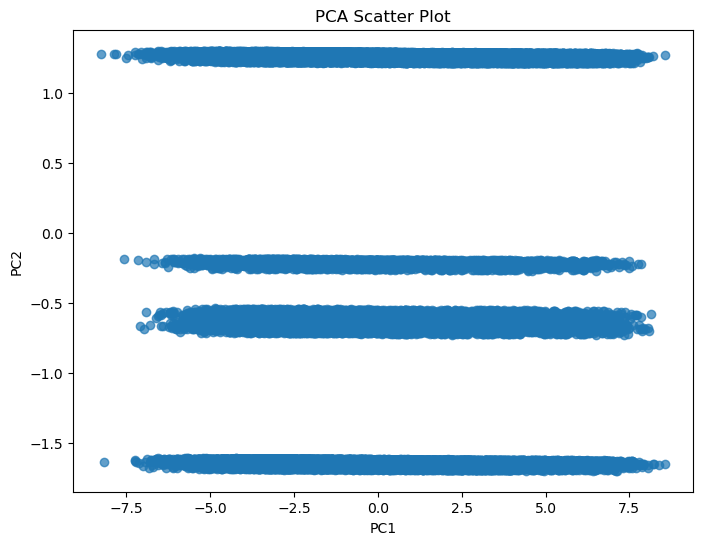

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_segmentation_pca[0],
    customer_segmentation_pca[1],
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot')

plt.show()

In [30]:
# Making a new dataframe with first 4 principal components as columns and original features as indices
cols = ['PC1', 'PC2', 'PC3', 'PC4','PC5']

pc1 = pd.DataFrame(np.round(pca1.components_.T[:, 0:5], 2), index = customer_segmentation_scaled.columns, columns = cols)
pc1

,PC1,PC2,PC3,PC4,PC5
total_vol,0.33,-0.00,-0.00,-0.00,-0.00
total_dpm,0.25,0.00,-0.00,-0.00,-0.00
national_volume,0.32,0.00,-0.00,0.00,0.00
international_volume,0.30,-0.00,0.00,-0.00,-0.00
supplied_by_bp_vol,0.31,-0.00,-0.00,0.00,0.00
non_supplied_by_bp_vol,0.31,0.00,0.00,-0.00,-0.00
non_street_heavy_sites_volume,0.31,-0.00,0.00,-0.00,-0.00
street_heavy_sites_volume,0.31,-0.00,0.00,0.00,-0.00
dealer_heavy_site_type_volume,0.30,-0.00,0.00,-0.00,0.00
bp_heavy_site_type_volume,0.31,0.00,-0.00,0.00,-0.00


**Observations:**

- The first principal component, PC1, seems to be related to all the volumes, with the exclusion of international volume
- The second principal component, PC2, seems to be related to international volume and price types.
- The third principal component, PC3, seems to be capturing variation in the international volume, non Supplied BP Volume  and contract age.
- The fourth principal component, PC4, seems to be associated with product category and pricing types
- The fifth principal component, PC4, seems to be associated with  pricing types

In [31]:
import pandas as pd

import numpy as np

import matplotlib.pylab as plt

import seaborn as sns

# To scale the data using z-score 
from sklearn.preprocessing import StandardScaler

# Importing clustering algorithms
from sklearn.cluster import KMeans

from sklearn.mixture import GaussianMixture

#from sklearn_extra.cluster import KMedoids

from sklearn.cluster import AgglomerativeClustering

from sklearn.cluster import DBSCAN

# Silhouette score
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [32]:
data_for_k_means = customer_segmentation_pca.iloc[:,0:5]
data_for_k_means

,0,1,2,3,4
0,-3.716486,-1.640884,1.496633,-0.651504,-0.829918
1,-2.093467,1.260428,1.525501,-0.585629,-0.274197
2,-3.003439,1.248284,-0.220141,2.466341,-0.405967
3,3.984749,-1.626445,-1.579310,-0.926774,-0.715731
4,-2.148697,1.264575,1.524419,-0.583652,-0.275525
...,...,...,...,...,...
69140,1.069026,1.253032,1.520843,-0.575252,-0.309583
69141,-0.447571,-1.629080,-1.580361,-0.909961,-0.760506
69142,-1.897548,-0.214753,-0.038611,0.124538,0.161599
69143,1.611492,1.256088,1.519923,-0.571984,-0.317134


In [33]:
# Empty dictionary to store the SSE for each value of K
sse = {} 

# Iterate for a range of Ks and fit the scaled data to the algorithm. 
# Use inertia attribute from the clustering object and store the inertia value for that K 
for k in range(1, 12):
    kmeans = KMeans(n_clusters = k, random_state = 42).fit(data_for_k_means)
    
    sse[k] = kmeans.inertia_
print (sse)

{1: 1016744.5412614307, 2: 568917.0922748011, 3: 465915.41378124064, 4: 434154.75025542907, 5: 391625.10844976513, 6: 358487.2398436435, 7: 335184.1523796397, 8: 320090.451116686, 9: 304389.8819168221, 10: 286716.94265894376, 11: 258452.56809054845}


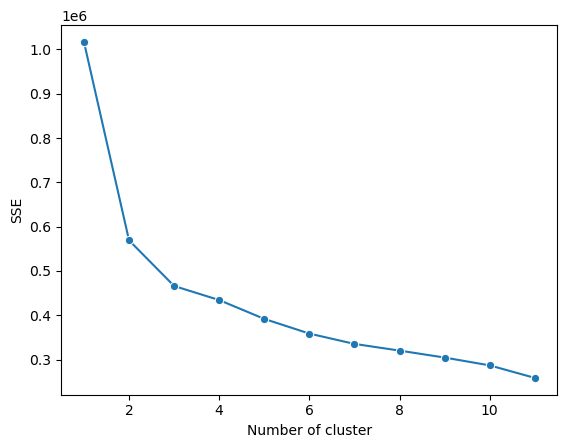

In [34]:
# Elbow plot
plt.figure()

sns.lineplot(
    x=list(sse.keys()),
    y=list(sse.values()),
    marker='o'
)
plt.xlabel("Number of cluster")

plt.ylabel("SSE")

plt.show()

### 4 or 5 cluster look ideal from the look of the elbow plot

In [35]:
# Empty dictionary to store the Silhouette score for each value of K
sc = {} 

# Iterate for a range of Ks and fit the scaled data to the algorithm. Store the Silhouette score for that K 
for k in range(3, 7):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(data_for_k_means)
    labels = kmeans.predict(data_for_k_means)
    
    sc[k] = silhouette_score(data_for_k_means, labels)


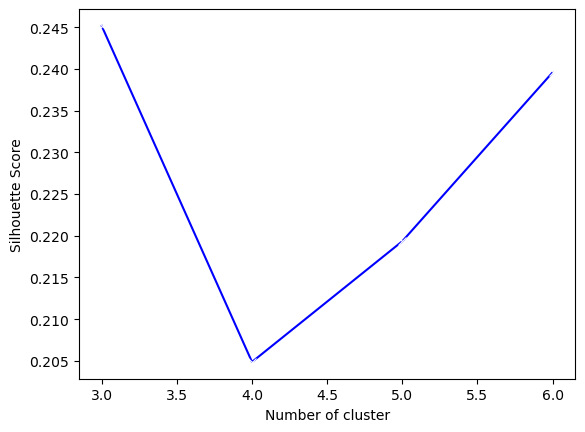

In [36]:
# Elbow plot
plt.figure()

sns.lineplot(
    x=list(sc.keys()),
    y=list(sc.values()),
    marker='x',
    color='blue',
    linestyle='-'
)

plt.xlabel("Number of cluster")

plt.ylabel("Silhouette Score")

plt.show()

5 cluster look more ideal from the above.

### Check for best Model and Cluster size based on silhouette score ###

In [38]:
from sklearn.cluster import KMeans

def apply_kmeans(n_clusters):
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init='auto'
    )

    labels = kmeans.fit_predict(customer_segmentation_pca.iloc[:, 0:5])

    customer_segmentation['KMeans_Labels'] = labels
    customer_segmentation_cp['KMeans_Labels'] = labels
    customer_segmentation_scaled['KMeans_Labels'] = labels
    customer_segmentation_pca['KMeans_Labels'] = labels

    print(
        f"k={k}: "
        f"KMeans={silhouette_score(customer_segmentation_pca.iloc[:,0:5], km_labels):.3f}, "
    )


In [39]:
apply_kmeans(n_clusters=5)

k=5: KMeans=0.219, 


In [40]:
customer_segmentation['KMeans_Labels'].value_counts()

KMeans_Labels
4    17637
0    17602
2    15254
3     9404
1     9248
Name: count, dtype: int64

In [41]:
def cluster_summary(df, cluster):
    drop_cols = [
        'parent_name',
       # 'supplied_by_bp_median_rebate_cpl',
       # 'non_supplied_by_bp_median_rebate_cpl',
      #  'non_street_heavy_sites_median_rebate_cpl',
       # 'street_heavy_sites_median_rebate_cpl',
      #  'dealer_heavy_sites_median_rebate_cpl',
     #   'bp_heavy_sites_median_rebate_cpl',
      #  'overall_median_rebate_cpl',
       # 'total_rebate_amount'
    ]

    df_group = df.drop(columns=drop_cols, errors="ignore")

    mean = df_group.groupby(cluster).mean(numeric_only=True)
    median = df_group.groupby(cluster).median(numeric_only=True)

    df_kmeans = pd.concat(
        [mean, median],
        keys=["Mean", "Median"]
    )

    df_kmeans.index = [
        f"group_{group} {stat}"
        for stat, group in df_kmeans.index
    ]

    return df_kmeans.T.round(0)

In [42]:
cluster_summary(customer_segmentation, 'KMeans_Labels')

,group_0 Mean,group_1 Mean,group_2 Mean,group_3 Mean,group_4 Mean,group_0 Median,group_1 Median,group_2 Median,group_3 Median,group_4 Median
total_vol,2318.0,13107.0,77740.0,2675.0,13635.0,2132.0,10663.0,61670.0,2380.0,11745.0
total_dpm,162.0,639.0,3577.0,178.0,670.0,144.0,527.0,2802.0,161.0,578.0
national_volume,1439.0,8067.0,47712.0,1653.0,8425.0,1252.0,6247.0,37656.0,1369.0,7000.0
international_volume,880.0,5040.0,30028.0,1022.0,5210.0,719.0,3741.0,22977.0,811.0,4161.0
supplied_by_bp_vol,1230.0,6947.0,41038.0,1409.0,7217.0,1046.0,5303.0,32117.0,1160.0,5868.0
non_supplied_by_bp_vol,1089.0,6160.0,36701.0,1266.0,6419.0,914.0,4583.0,28518.0,1014.0,5220.0
non_street_heavy_sites_volume,1266.0,7172.0,42366.0,1462.0,7414.0,1084.0,5499.0,33350.0,1204.0,6105.0
street_heavy_sites_volume,1053.0,5935.0,35374.0,1213.0,6221.0,869.0,4439.0,27320.0,971.0,5006.0
dealer_heavy_site_type_volume,1012.0,5763.0,34099.0,1175.0,5984.0,829.0,4285.0,26376.0,931.0,4769.0
bp_heavy_site_type_volume,1306.0,7343.0,43641.0,1499.0,7651.0,1111.0,5544.0,34236.0,1247.0,6305.0


In [43]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_profiles(df, cluster_col):
    """
    Creates boxplots of all numeric variables by cluster.
    """

    cols_to_drop = [
        'parent_name',
        'supplied_by_bp_median_rebate_cpl',
        'non_supplied_by_bp_median_rebate_cpl',
        'non_street_heavy_sites_median_rebate_cpl',
        'street_heavy_sites_median_rebate_cpl',
        'dealer_heavy_sites_median_rebate_cpl',
        'bp_heavy_sites_median_rebate_cpl',
        'overall_median_rebate_cpl',
        'total_rebate_amount'
    ]

    plot_df = df.drop(columns=cols_to_drop, errors='ignore').copy()

    # All possible cluster-label columns to exclude from y-axis
    exclude_cols = [
        'KMeans_Labels',
        'GMM_Labels',
        'GmmLabels',
        'HCLabels',
        cluster_col
    ]

    cols_visualise = [
        col for col in plot_df.columns
        if col not in exclude_cols
        and pd.api.types.is_numeric_dtype(plot_df[col])
    ]

    print(f"Plotting {len(cols_visualise)} variables")

    if len(cols_visualise) == 0:
        print("No numeric columns available to plot after exclusions.")
        return

    n_cols = 4
    n_rows = math.ceil(len(cols_visualise) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = axes.flatten() if len(cols_visualise) > 1 else [axes]

    for i, col in enumerate(cols_visualise):
        sns.boxplot(
            data=plot_df,
            x=cluster_col,
            y=col,
            showfliers=False,
            ax=axes[i]
        )

        axes[i].set_title(col)
        axes[i].set_xlabel(cluster_col)
        axes[i].set_ylabel(col)

    for j in range(len(cols_visualise), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Plotting 21 variables


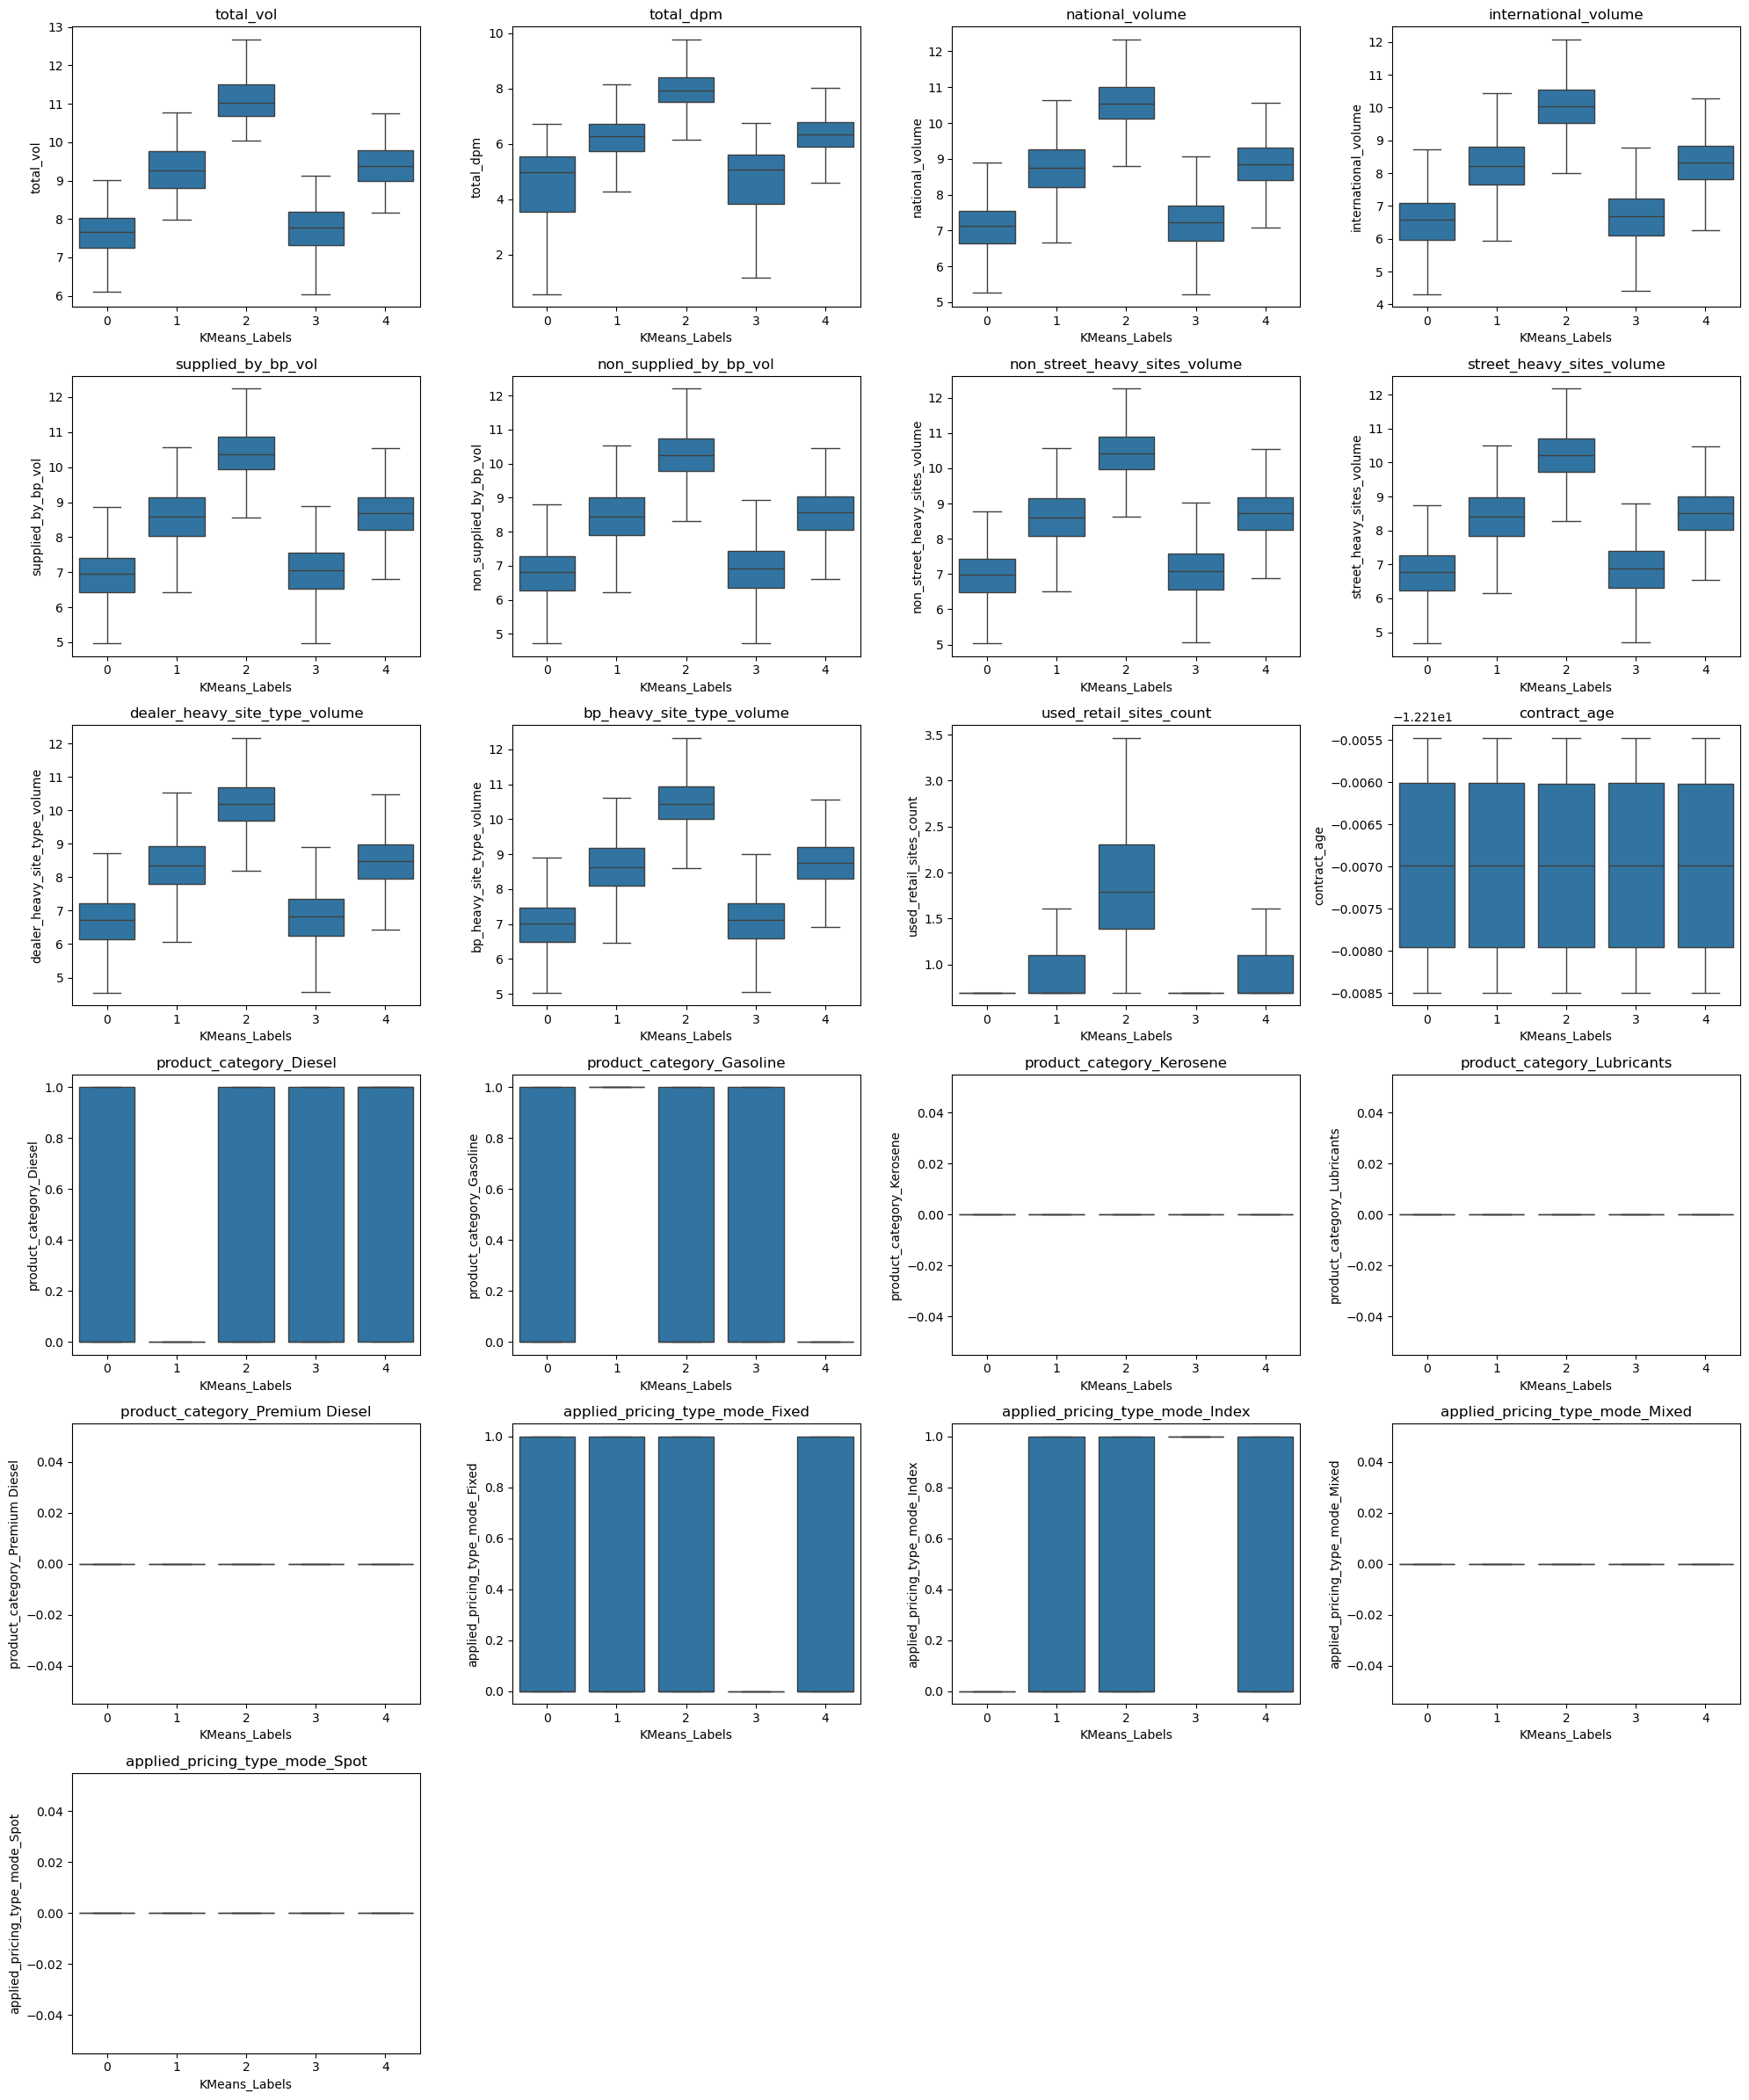

In [44]:
plot_cluster_profiles(customer_segmentation_cp, 'KMeans_Labels')

## Gaussian Mixture Model

In [45]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

def apply_gmm(n_clusters):
    X_cluster = customer_segmentation_pca.iloc[:, :5]

    gmm = GaussianMixture(
        n_components=n_clusters,
        random_state=42
    )

    labels = gmm.fit_predict(X_cluster)

    customer_segmentation['GmmLabels'] = labels
    customer_segmentation_cp['GmmLabels'] = labels
    customer_segmentation_scaled['GmmLabels'] = labels
    customer_segmentation_pca['GmmLabels'] = labels

    print(
        f"k={n_clusters}: "
        f"GMM={silhouette_score(X_cluster, labels):.3f}"
    )

In [46]:
apply_gmm(n_clusters = 5)

k=5: GMM=0.068


In [47]:
customer_segmentation['GmmLabels'].value_counts()

GmmLabels
4    27347
1    20631
3    14165
2     3508
0     3494
Name: count, dtype: int64

In [48]:
cluster_summary(customer_segmentation, 'GmmLabels')

,group_0 Mean,group_1 Mean,group_2 Mean,group_3 Mean,group_4 Mean,group_0 Median,group_1 Median,group_2 Median,group_3 Median,group_4 Median
total_vol,23618.0,23192.0,22522.0,23275.0,23542.0,8056.0,7865.0,8201.0,7787.0,8137.0
total_dpm,1132.0,1100.0,1080.0,1107.0,1122.0,429.0,415.0,425.0,409.0,419.0
national_volume,14636.0,14236.0,13886.0,14252.0,14496.0,4761.0,4546.0,4793.0,4507.0,4690.0
international_volume,8982.0,8956.0,8636.0,9024.0,9046.0,2717.0,2645.0,2798.0,2614.0,2673.0
supplied_by_bp_vol,12627.0,12320.0,11718.0,12296.0,12390.0,3979.0,3836.0,3888.0,3804.0,3880.0
non_supplied_by_bp_vol,10991.0,10872.0,10804.0,10979.0,11151.0,3422.0,3316.0,3528.0,3306.0,3425.0
non_street_heavy_sites_volume,12596.0,12627.0,12349.0,12803.0,12805.0,4087.0,3983.0,4165.0,3920.0,4074.0
street_heavy_sites_volume,11022.0,10565.0,10173.0,10473.0,10737.0,3360.0,3195.0,3257.0,3181.0,3277.0
dealer_heavy_site_type_volume,10299.0,10135.0,9898.0,10246.0,10346.0,3105.0,3035.0,3208.0,3074.0,3074.0
bp_heavy_site_type_volume,13319.0,13058.0,12625.0,13029.0,13196.0,4291.0,4029.0,4141.0,3984.0,4193.0


Plotting 21 variables


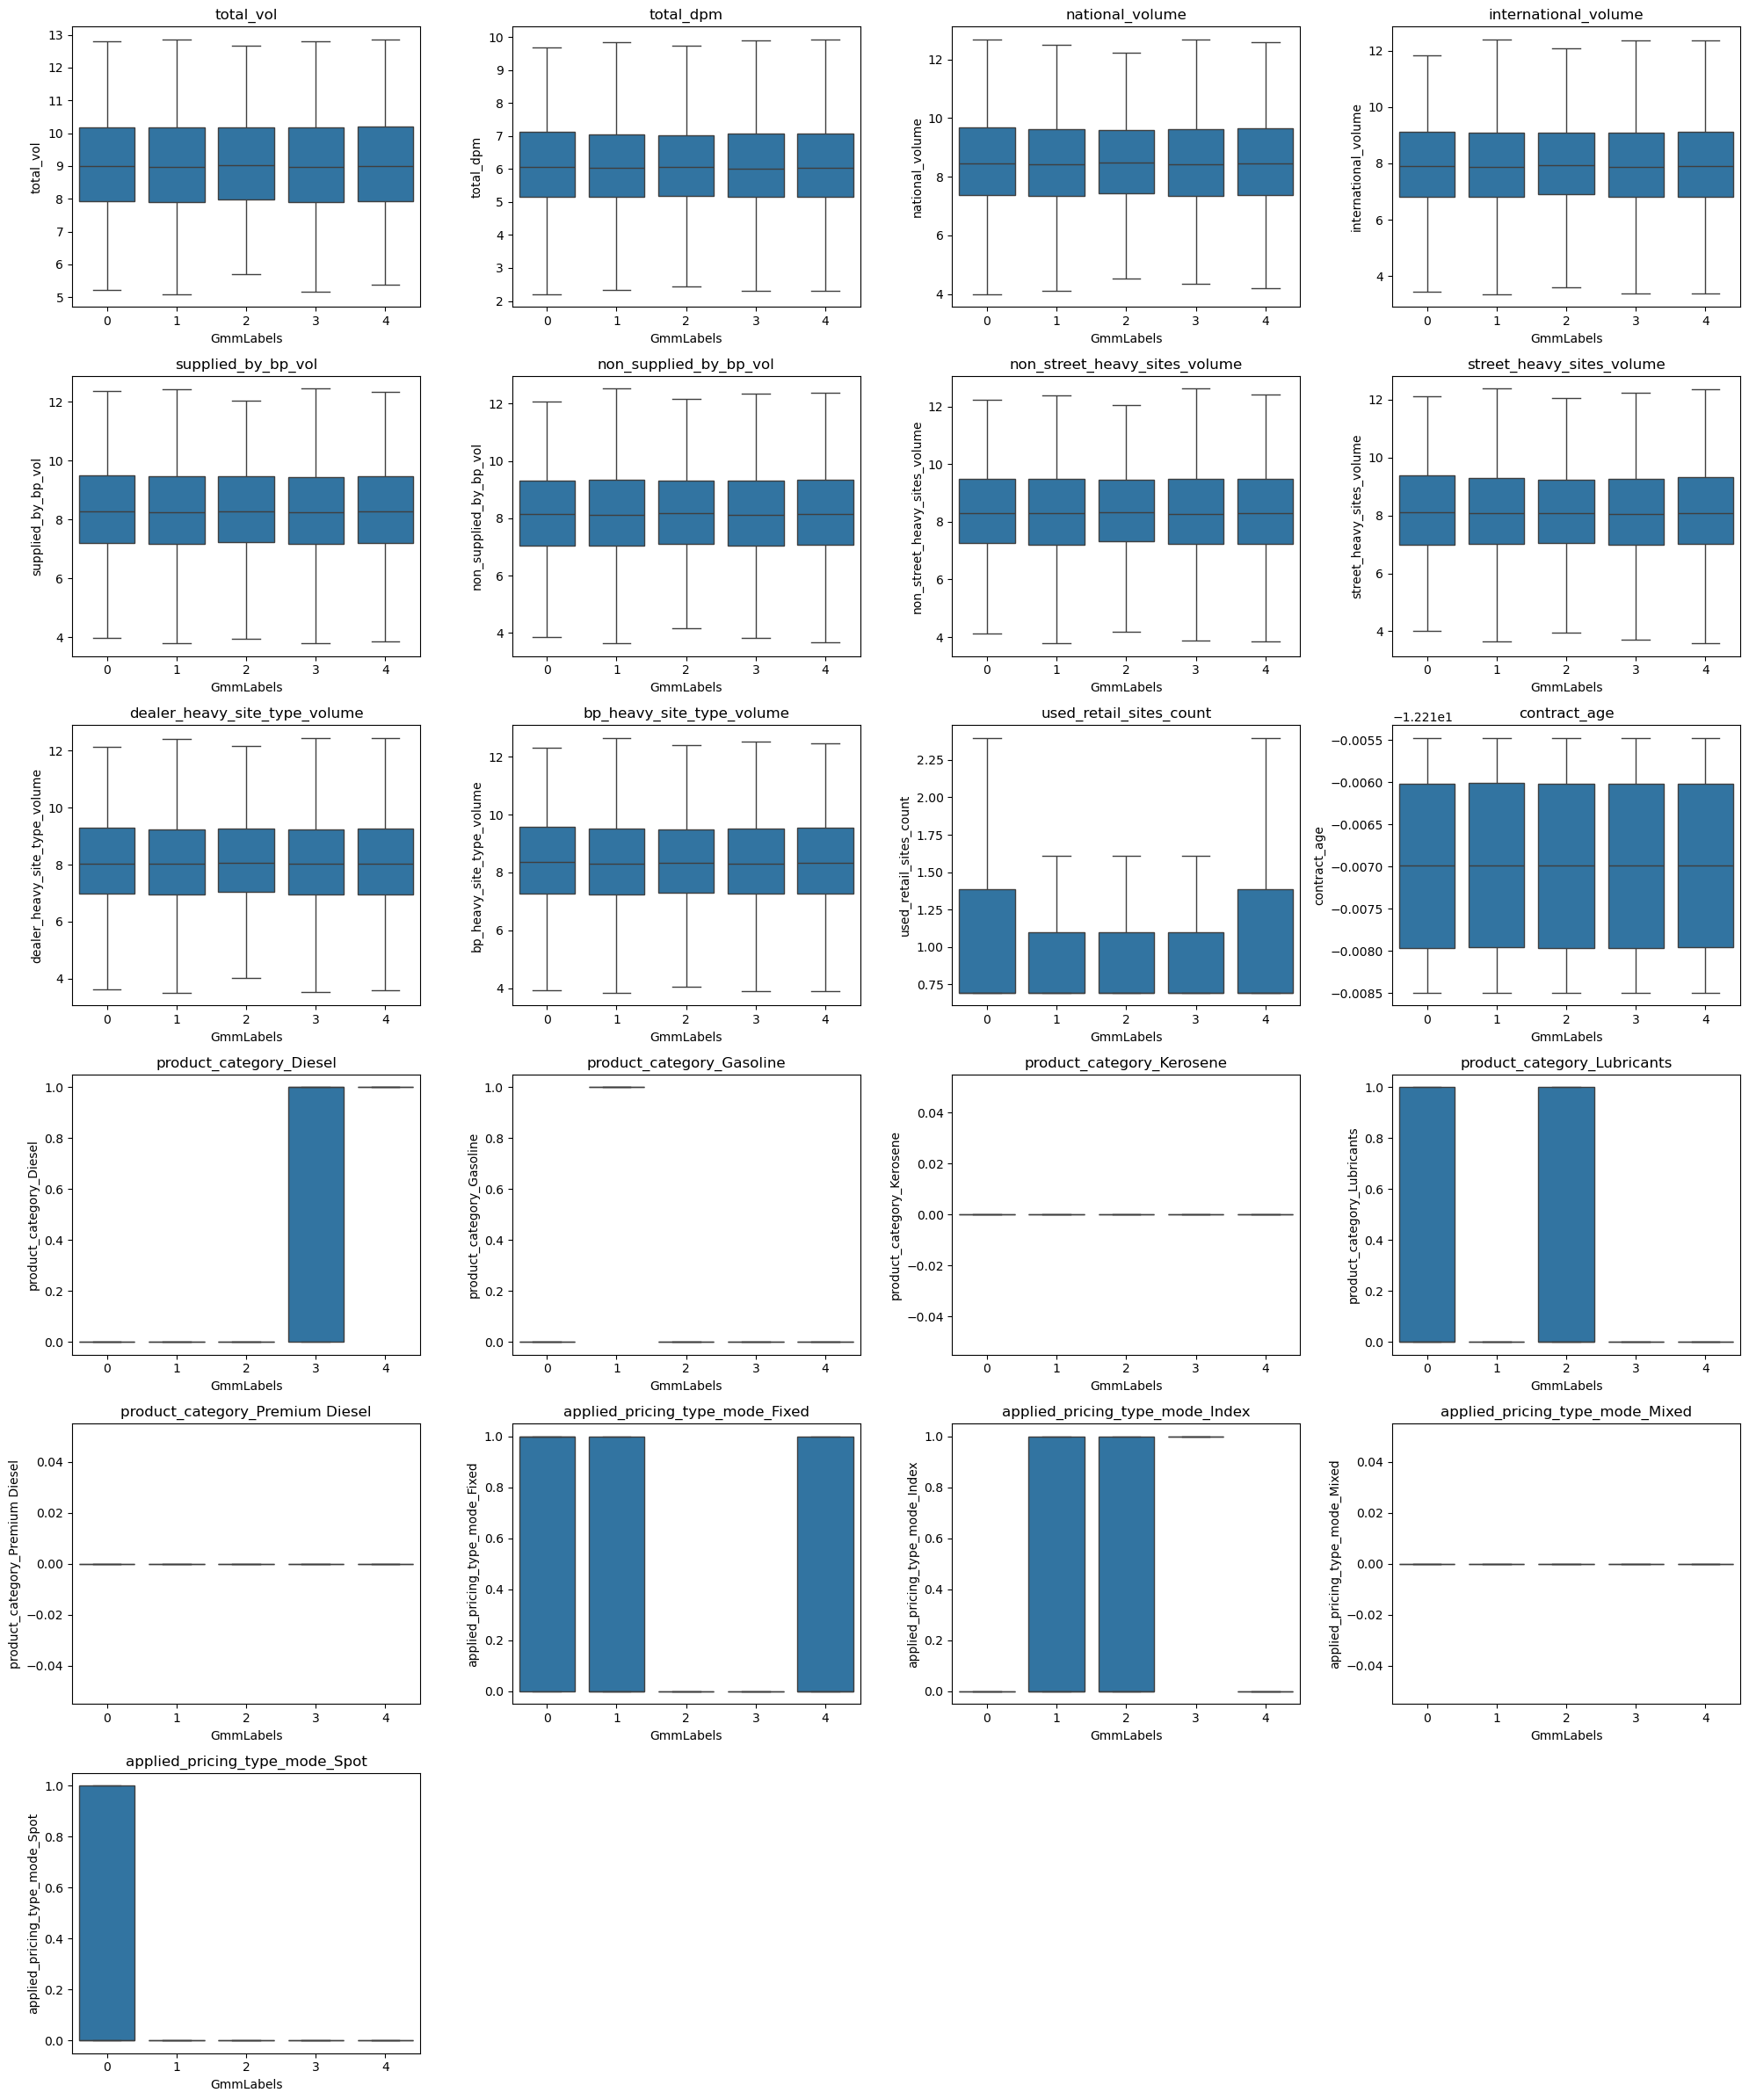

In [49]:
plot_cluster_profiles(customer_segmentation_cp, 'GmmLabels')

### Cluster Benchmark

In [50]:
cluster_benchmark = (
    customer_segmentation.groupby('KMeans_Labels')['overall_median_rebate_cpl']
      .median()
      .rename('cluster_benchmark_cpl')
)

df = customer_segmentation.merge(
    cluster_benchmark,
    on='KMeans_Labels',
    how='left'
)

### Rebate Gap

In [51]:
df['rebate_gap_cpl'] = (
    df['overall_median_rebate_cpl']
    - df['cluster_benchmark_cpl']
)

In [52]:
df.head()

,parent_name,product_category,total_vol,total_dpm,national_volume,international_volume,supplied_by_bp_vol,non_supplied_by_bp_vol,non_street_heavy_sites_volume,street_heavy_sites_volume,...,bp_heavy_sites_median_rebate_cpl,overall_median_rebate_cpl,used_retail_sites_count,total_rebate_amount,applied_pricing_type_mode,contract_age,KMeans_Labels,GmmLabels,cluster_benchmark_cpl,rebate_gap_cpl
0,Prime Partners Group,Gasoline,1264.10,135.44,773.79,490.31,492.93,771.17,620.78,643.32,...,6.30,6.95,1,0.00,Index,-202096,3,1,5.93,1.02
1,Crown Fleet Partners,Diesel,3131.28,370.32,1026.52,2104.76,2660.31,470.97,2155.82,975.46,...,9.30,8.35,1,443.02,Index,-202096,3,3,5.93,2.42
2,Prime Distribution Inc,Diesel,1568.87,152.72,799.82,769.05,1083.22,485.65,675.88,892.99,...,7.49,5.87,3,0.00,Spot,-202290,0,4,5.93,-0.06
3,Prime Supply Partners,Gasoline,57187.63,2503.23,46020.13,11167.50,24731.91,32455.72,45298.48,11889.15,...,5.60,3.54,4,1749.98,Fixed,-202393,2,1,5.92,-2.38
4,Eastern Partners Co,Diesel,3181.65,262.70,2580.88,600.77,821.67,2359.98,2532.04,649.61,...,NaN,6.40,1,226.81,Index,-202096,3,3,5.93,0.47


In [53]:
cluster_std = (
    df.groupby('KMeans_Labels')['overall_median_rebate_cpl']
      .std()
      .rename('cluster_std')
)

df = df.merge(
    cluster_std,
    on='KMeans_Labels',
    how='left'
)

df['z_score'] = (
    df['overall_median_rebate_cpl']
    - df['cluster_benchmark_cpl']
) / df['cluster_std']

In [54]:
df['rebate_flag'] = 'In Range'

df.loc[df['z_score'] > 1.5, 'rebate_flag'] = 'Over Rebated'
df.loc[df['z_score'] < -1.5, 'rebate_flag'] = 'Under Rebated'

In [55]:
df.head()

,parent_name,product_category,total_vol,total_dpm,national_volume,international_volume,supplied_by_bp_vol,non_supplied_by_bp_vol,non_street_heavy_sites_volume,street_heavy_sites_volume,...,total_rebate_amount,applied_pricing_type_mode,contract_age,KMeans_Labels,GmmLabels,cluster_benchmark_cpl,rebate_gap_cpl,cluster_std,z_score,rebate_flag
0,Prime Partners Group,Gasoline,1264.10,135.44,773.79,490.31,492.93,771.17,620.78,643.32,...,0.00,Index,-202096,3,1,5.93,1.02,1.189493,0.857508,In Range
1,Crown Fleet Partners,Diesel,3131.28,370.32,1026.52,2104.76,2660.31,470.97,2155.82,975.46,...,443.02,Index,-202096,3,3,5.93,2.42,1.189493,2.034480,Over Rebated
2,Prime Distribution Inc,Diesel,1568.87,152.72,799.82,769.05,1083.22,485.65,675.88,892.99,...,0.00,Spot,-202290,0,4,5.93,-0.06,1.197101,-0.050121,In Range
3,Prime Supply Partners,Gasoline,57187.63,2503.23,46020.13,11167.50,24731.91,32455.72,45298.48,11889.15,...,1749.98,Fixed,-202393,2,1,5.92,-2.38,1.190247,-1.999585,Under Rebated
4,Eastern Partners Co,Diesel,3181.65,262.70,2580.88,600.77,821.67,2359.98,2532.04,649.61,...,226.81,Index,-202096,3,3,5.93,0.47,1.189493,0.395126,In Range


In [56]:
df['rebate_opportunity_gbp'] = (
    df['rebate_gap_cpl']
    * df['total_vol']
    / 100
)

df['rebate_opportunity_gbp'] = (
    df['rebate_opportunity_gbp']
    .clip(lower=0)
)

In [57]:
renewal_targets = (
    df[df['rebate_flag'] == 'Over Rebated']
      .sort_values(
          'rebate_opportunity_gbp',
          ascending=False
      )
      [[
          'parent_name',
          'KMeans_Labels',
          'total_vol',
          'overall_median_rebate_cpl',
          'cluster_benchmark_cpl',
          'rebate_gap_cpl',
          'rebate_opportunity_gbp'
      ]]
)

renewal_targets.head(20)

,parent_name,KMeans_Labels,total_vol,overall_median_rebate_cpl,cluster_benchmark_cpl,rebate_gap_cpl,rebate_opportunity_gbp
55174,Urban Supply LLC,2,285764.45,9.66,5.92,3.74,10687.590430
60148,Atlas Trucking Inc,2,182302.02,10.00,5.92,4.08,7437.922416
5164,North Supply Partners,2,288948.06,8.28,5.92,2.36,6819.174216
48374,Silver Distribution Partners,2,290489.47,8.17,5.92,2.25,6536.013075
30567,Liberty Distribution Inc,2,153566.81,9.94,5.92,4.02,6173.385762
37381,Silver Services Partners,2,205538.89,8.92,5.92,3.00,6166.166700
65553,Valley Motors LLC,2,241373.76,8.46,5.92,2.54,6130.893504
27664,North Group Partners,2,178477.45,9.28,5.92,3.36,5996.842320
21280,Summit Motors Co,2,163710.05,9.17,5.92,3.25,5320.576625
11745,Green Partners Partners,2,165379.39,9.12,5.92,3.20,5292.140480


In [58]:
print(
    f"Potential rebate recovery: "
    f"£{df['rebate_opportunity_gbp'].sum():,.0f}"
)

Potential rebate recovery: £7,606,697


In [59]:
df['rebate_variance_pct'] = (
    (df['overall_median_rebate_cpl']
     - df['cluster_benchmark_cpl'])
    / df['cluster_benchmark_cpl']
) * 100

In [60]:
df.head()

,parent_name,product_category,total_vol,total_dpm,national_volume,international_volume,supplied_by_bp_vol,non_supplied_by_bp_vol,non_street_heavy_sites_volume,street_heavy_sites_volume,...,contract_age,KMeans_Labels,GmmLabels,cluster_benchmark_cpl,rebate_gap_cpl,cluster_std,z_score,rebate_flag,rebate_opportunity_gbp,rebate_variance_pct
0,Prime Partners Group,Gasoline,1264.10,135.44,773.79,490.31,492.93,771.17,620.78,643.32,...,-202096,3,1,5.93,1.02,1.189493,0.857508,In Range,12.893820,17.200675
1,Crown Fleet Partners,Diesel,3131.28,370.32,1026.52,2104.76,2660.31,470.97,2155.82,975.46,...,-202096,3,3,5.93,2.42,1.189493,2.034480,Over Rebated,75.776976,40.809444
2,Prime Distribution Inc,Diesel,1568.87,152.72,799.82,769.05,1083.22,485.65,675.88,892.99,...,-202290,0,4,5.93,-0.06,1.197101,-0.050121,In Range,0.000000,-1.011804
3,Prime Supply Partners,Gasoline,57187.63,2503.23,46020.13,11167.50,24731.91,32455.72,45298.48,11889.15,...,-202393,2,1,5.92,-2.38,1.190247,-1.999585,Under Rebated,0.000000,-40.202703
4,Eastern Partners Co,Diesel,3181.65,262.70,2580.88,600.77,821.67,2359.98,2532.04,649.61,...,-202096,3,3,5.93,0.47,1.189493,0.395126,In Range,14.953755,7.925801
